## Introduction

In [1]:
import hvplot.xarray
import numpy as np
import xarray as xr
import pandas as pd

In [56]:
def load_merged_argo_dataset_and_tumo(time_smoothing, lat_bounds = None):
    ds_argo_merged = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}.nc')
    t_umo_obs = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/t_umo_obs_2000ref.nc')

    t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)#, method = 'nearest')
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs

In [57]:
# Load the argo_dataset and the ground truth dataset

import xarray as xr
time_smoothing = '90D'

lat_bounds = (25, 27)


ds_argo_merged, t_umo_obs = load_merged_argo_dataset_and_tumo(time_smoothing)#, lat_bounds = lat_bounds)

In [58]:
ds_argo_merged

<xarray.Dataset>
Dimensions:       (time: 73, z: 242, pos: 690)
Coordinates:
  * time          (time) datetime64[ns] 2004-04-02 2004-07-01 ... 2021-12-29
  * z             (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0
    pressure      (z) float64 ...
    lon           (time, pos) float64 ...
    lat           (time, pos) float64 ...
    time_1d       (time, pos) datetime64[ns] ...
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 683 684 685 686 687 688 689
Data variables:
    temperature   (time, z, pos) float64 ...
    salinity      (time, z, pos) float64 ...
    profile_mask  (time, pos) float64 ...
    ct            (time, z, pos) float64 ...
    rho           (time, z, pos) float64 ...

## Latitude bounds (no clue which code this is)

In [41]:
import numpy as np
lon_min , lon_max = ds_argo_merged.lon.min(),ds_argo_merged.lon.max() 
lat_min , lat_max = ds_argo_merged.lat.min(),ds_argo_merged.lat.max() 


lon_bin = np.arange(lon_min, lon_max, 6) 
lat_bin = np.arange(lat_min, lat_max, 6) 



In [42]:
lon_min, lon_max, lat_min, lat_max

(<xarray.DataArray 'lon' ()>
 array(-82.87867737),
 <xarray.DataArray 'lon' ()>
 array(-10.6491003),
 <xarray.DataArray 'lat' ()>
 array(23.66731071),
 <xarray.DataArray 'lat' ()>
 array(31.62044907))

In [43]:
lon_bin = np.linspace(-88, -10, 30)
lon_bin, np.diff(lon_bin)

(array([-88.        , -85.31034483, -82.62068966, -79.93103448,
        -77.24137931, -74.55172414, -71.86206897, -69.17241379,
        -66.48275862, -63.79310345, -61.10344828, -58.4137931 ,
        -55.72413793, -53.03448276, -50.34482759, -47.65517241,
        -44.96551724, -42.27586207, -39.5862069 , -36.89655172,
        -34.20689655, -31.51724138, -28.82758621, -26.13793103,
        -23.44827586, -20.75862069, -18.06896552, -15.37931034,
        -12.68965517, -10.        ]),
 array([2.68965517, 2.68965517, 2.68965517, 2.68965517, 2.68965517,
        2.68965517, 2.68965517, 2.68965517, 2.68965517, 2.68965517,
        2.68965517, 2.68965517, 2.68965517, 2.68965517, 2.68965517,
        2.68965517, 2.68965517, 2.68965517, 2.68965517, 2.68965517,
        2.68965517, 2.68965517, 2.68965517, 2.68965517, 2.68965517,
        2.68965517, 2.68965517, 2.68965517, 2.68965517]))

In [44]:
lat_bin = [20,26,32]
lat_bin = np.linspace(20, 32, 50)
lon_bin = np.linspace(-88, -10, 30)
# lon_bin = [-88, -82, -76, -70, -64, -58, -52, -46, -40, -34, -28, -22, -16, -10]

lon_cent = lon_bin[:-1] + np.diff(lon_bin)/2
lat_cent = lat_bin[:-1] + np.diff(lat_bin)/2

In [45]:
%%time
def group_lat(x):
    # x is a DataFrame of group values
    # now find the value of the longitude box to append to the dictionary key
    value = np.ones(1)
    value[0] = x.lon.mean()
    idx = (np.abs(lon_cent - value)).argmin()
    lokey = lon_cent[idx] # longitude value of the box

    # compute groups for the latitude
    y = x.groupby_bins('lat', lat_bin, labels=lat_cent)
    y = dict(y)
    # replace the old key with the new key: lon,lat
    key = np.asarray((list(y.keys()))) # get dict keys as array
    newkey = np.stack((np.ones(len(key))*lokey,key),axis=1)
    newkey = tuple(newkey.tolist())
    key = tuple(y.keys()) # get dict keys as list

    for i in range(len(key)):
        y[tuple(newkey[i])] = y[key[i]]
        del y[key[i]]  
    return y


CPU times: user 20 µs, sys: 1e+03 ns, total: 21 µs
Wall time: 43.2 µs


In [46]:
def bin_argo_time_slice(ds_argo_ti):

    #geop_mean = geop1.groupby_bins('lon', lon_bin, labels=lon_cent).apply(group_lat)
    geop_mean = ds_argo_ti.groupby_bins('lon', lon_bin, labels=lon_cent)
    geop_mean = dict(geop_mean)


    l = 0
    geo_grid = dict()

    for x in list(geop_mean.keys()):
        y = group_lat(geop_mean[x])
        if l == 0:
            geo_grid = y
        else:
            geo_grid.update(y)
        l += 1
    
    l = 0
    m = np.zeros((len(tuple(geo_grid.keys())),4))
    d = np.asarray(list(geo_grid.keys()))

    gp = xr.Dataset(
        {
            'rho': (['lat','lon', 'z'],np.full((lat_cent.shape[0],lon_cent.shape[0], ds_argo_ti.z.shape[0]), np.nan)),
        },
        coords={
            'lon': (['lon'],lon_cent),
            'lat': (['lat'],lat_cent),
            'z': ds_argo_ti.z
        }
    )

    for k in range(d.shape[0]):
        e = tuple(d[k])
        #m[l,2] = geo_grid[e].z.mean()

        if geo_grid[e].pos.shape[0] < 1:
            continue

        try:
            gp['rho'].loc[dict(lat=d[k][1], lon=d[k][0])] = geo_grid[e].rho.mean('pos')
        except:
            print(geo_grid[e].rho.mean('pos'))
            raise ValueError('Error')
        # gp['z'].loc[dict(lat=d[k][1], lon=d[k][0])] = geo_grid[e].z
        #gp.loc[dict(lat=m[0,1], lon=m[0,0])]
        l +=1

    return gp

In [47]:
# for i in range(0,ds_argo_merged.time.shape[0]):
#     binned_ti = bin_argo_time_slice(ds_argo_merged.isel(time = i))
    
# binned_ti.ass


interpolated_merged_argo = xr.concat([bin_argo_time_slice(ds_argo_merged.isel(time = i)) for i in range(ds_argo_merged.time.shape[0])], dim = 'time').assign_coords(time = ds_argo_merged.time)


KeyboardInterrupt: 

In [ ]:
# standardize the rho values at the bins
from copy import deepcopy


rho_mean = interpolated_merged_argo.rho.mean(['time', 'lon', 'lat'])
rho_std = interpolated_merged_argo.rho.std(['time', 'lon', 'lat', 'z'])

def standardize_rho(ds_pos, rho_mean=None, rho_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["rho"] = (ds_pos["rho"] - rho_mean) / rho_std
    return ds_pos

interpolated_merged_argo_std = standardize_rho(
    interpolated_merged_argo,
    rho_mean=rho_mean, 
    rho_std=rho_std,
)

In [ ]:
import hvplot.xarray


interpolated_merged_argo_std.isel(lat = 1, time = 50).rho.hvplot(x = 'lon', y = 'z')

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1545: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


:Image   [lon,z]   (rho)

In [ ]:
blocks_permuted_indices = np.concatenate([np.arange(starti, min(starti+12, interpolated_merged_argo.time.shape[0])) for starti in np.random.permutation(np.arange(0, interpolated_merged_argo.time.shape[0], 12))])

train_indices = blocks_permuted_indices[:int(.75 * blocks_permuted_indices.shape[0])]
test_indices = blocks_permuted_indices[int(.75 * blocks_permuted_indices.shape[0]):]

X_dataset = interpolated_merged_argo.rho.stack(feature = ('lat', 'lon', 'z')).fillna(0).values


train_X = X_dataset[train_indices]
test_X = X_dataset[test_indices]


train_y = t_umo_obs.dv_dz_times_X.values[train_indices]
test_y = t_umo_obs.dv_dz_times_X.values[test_indices]

In [ ]:
from sklearn.linear_model import Lasso, Ridge



ridge = Lasso(alpha=5).fit(train_X, train_y)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.329e-01, tolerance: 2.635e-01
  model = cd_fast.enet_coordinate_descent(


In [ ]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(10, 10, 10, 10), max_iter=1000, alpha=5,
                    solver='adam', verbose=10,  random_state=21,tol=0.000000001, learning_rate_init=1e-4, learning_rate='adaptive', validation_fraction=.1)

mlp.fit(train_X, train_y)

Iteration 1, loss = 172.11910602
Iteration 2, loss = 273.03244384
Iteration 3, loss = 55.54690028
Iteration 4, loss = 81.64439699
Iteration 5, loss = 65.78117902
Iteration 6, loss = 37.90241612
Iteration 7, loss = 27.94707913
Iteration 8, loss = 29.94755775
Iteration 9, loss = 32.72234550
Iteration 10, loss = 31.38964151
Iteration 11, loss = 25.83137368
Iteration 12, loss = 19.53154576
Iteration 13, loss = 17.08384722
Iteration 14, loss = 16.94231016
Iteration 15, loss = 15.94262322
Iteration 16, loss = 14.38026522
Iteration 17, loss = 12.34320599
Iteration 18, loss = 9.86092165
Iteration 19, loss = 8.68550761
Iteration 20, loss = 8.63411829
Iteration 21, loss = 8.72574199
Iteration 22, loss = 7.87601171
Iteration 23, loss = 7.22240428
Iteration 24, loss = 6.64603663
Iteration 25, loss = 6.09328937
Iteration 26, loss = 5.78839404
Iteration 27, loss = 5.45721498
Iteration 28, loss = 4.96978982
Iteration 29, loss = 4.35849088
Iteration 30, loss = 3.80417218
Iteration 31, loss = 3.5789481

MLPRegressor(alpha=5, hidden_layer_sizes=(10, 10, 10, 10),
             learning_rate='adaptive', learning_rate_init=0.0001, max_iter=1000,
             random_state=21, tol=1e-09, verbose=10)

In [ ]:
ridge.score(test_X, test_y)
# mlp.score(test_X, test_y)

-0.4769030208555176

In [ ]:
import pandas as pd

estimator = ridge

train_prediction = estimator.predict(train_X)
test_prediction = estimator.predict(test_X)

result_dataframe_train = pd.DataFrame({
    'time': t_umo_obs.time.data[train_indices],
    'true': train_y,
    'prediction': train_prediction,
})

result_dataframe_test = pd.DataFrame({
    'time': t_umo_obs.time.data[test_indices],
    'true': test_y,
    'prediction': test_prediction,
    'difference': test_y - test_prediction,
})

In [ ]:
result_dataframe_test.hvplot.line(x='time', y=['true', 'prediction'])

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:NdOverlay   [Variable]
   :Curve   [time]   (value)

In [ ]:
import hvplot.pandas
(
    result_dataframe_train.hvplot.line(x='time', y=['true', 'prediction'])
    + result_dataframe_test.hvplot.line(x='time', y=['true', 'prediction'])
    # + result_dataframe_test.hvplot.line(x='time', y='difference')
).cols(1)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will alwa

:Layout
   .NdOverlay.I  :NdOverlay   [Variable]
      :Curve   [time]   (value)
   .NdOverlay.II :NdOverlay   [Variable]
      :Curve   [time]   (value)

## Merge Argos with naive fix sized bins

In [7]:
lon_bin = np.linspace(-88, -10, 30)
 
lon_bined_argos = xr.concat([ds_argo_merged.isel(time = i).groupby_bins(group = 'lon', bins = lon_bin).mean() for i in range(ds_argo_merged.time.shape[0])], dim = 'time').assign_coords(time = ds_argo_merged.time)
lon_bined_argos = lon_bined_argos.rename(lon_bins = 'pos')

lon_bined_argos

<xarray.Dataset>
Dimensions:       (z: 242, pos: 29, time: 653)
Coordinates:
  * z             (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0
  * pos           (pos) object (-88.0, -85.31] ... (-12.69, -10.0]
  * time          (time) datetime64[ns] 2004-04-02 2004-04-12 ... 2022-02-07
    pressure      (z) float64 4.82e+03 4.8e+03 4.78e+03 ... 40.0 20.0 0.0
Data variables:
    temperature   (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan
    salinity      (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan
    profile_mask  (time, pos) float64 nan nan nan nan nan ... nan nan 1.0 nan
    ct            (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan
    rho           (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan

## Calculate transport between the argo bins

In [5]:
dv_dz_obs = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_obs.nc')
dv_dz_obs = dv_dz_obs.resample(time = time_smoothing).mean()
dv_dz_obs

<xarray.Dataset>
Dimensions:        (z: 242, time: 653)
Coordinates:
  * z              (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0
  * time           (time) datetime64[ns] 2004-04-02 2004-04-12 ... 2022-02-07
Data variables:
    dv_dz_times_X  (time, z) float64 -1.81 -1.795 -1.728 -1.664 ... nan nan nan

In [6]:

def calc_umo_tranport(ds_pos, obs_dv_dz = None):

    g = 9.81
    f = 2 * 7.292116E-5 * np.sin(np.deg2rad(26.5))
    rho0 = 1025.0
    zref = -4800

    rho_diff = xr.concat(
            [
                (
                    ds_pos.isel(pos=start_i + 1).squeeze(drop=True).rho
                    - ds_pos.isel(pos=start_i).squeeze(drop=True).rho
                ).assign_coords(box=f"{start_i}_{start_i+1}")
                for start_i in range(ds_pos.pos.shape[0] - 1)
            ],
            dim="box"
        )

    dv_dz = (- rho_diff * g / f / rho0).sum("box").where(
                (~(- rho_diff * g / f / rho0).isnull()).sum("box") > 0
            ).rename("dv_dz_times_X")

    if obs_dv_dz is not None:

        dv_dz = xr.where(
            dv_dz.where(dv_dz.z > -1000).isnull(),
            dv_dz_obs.sel(time = ds_argo_merged.time[i], method= 'nearest').dv_dz_times_X,
            dv_dz
        )

    # # cut the surface 
    dv_dz = dv_dz.where(dv_dz.z < -150)

    _dv_dz = dv_dz.isel(z=slice(-40, None))
    dv_dz_fillup = xr.where(
        ~dv_dz.isnull(),
        dv_dz,
        (_dv_dz.isel(z=0) + _dv_dz.diff("z").ffill("z").cumsum("z")).interp(z=dv_dz.z)
    )
    
    dv_dz = dv_dz_fillup
    
    transp_umo = (-(
            ((dv_dz.isel(z=slice(None, None, -1)).cumsum("z") * 20.0))
            - ((dv_dz.isel(z=slice(None, None, -1)).cumsum("z") * 20.0)).sel(z=zref, method="nearest")
        ).cumsum("z") * 20.0 / 1e6).sel(z=-1000, method="nearest")

    return transp_umo, dv_dz

In [7]:
transports = []
dv_dz_ts = []
mask_with_pos = []
for i in range(ds_argo_merged.time.shape[0]):

    grouped_lons = ds_argo_merged.isel(time = i).groupby_bins(group = 'lon', bins = lon_bin)

    lon_mask_deeper_than1000dbar = grouped_lons.count().rho.sum('z') > (~ds_argo_merged.z.where(ds_argo_merged.z > -1000).isnull()).sum()
    lon_mask_deeper_than1000dbar = lon_mask_deeper_than1000dbar.rename(lon_bins = 'pos')

    ds_pos = grouped_lons.mean().rename(lon_bins = 'pos').where(lon_mask_deeper_than1000dbar, drop = True)
    if ds_pos.pos.shape[0] < 2:
        continue
    mask_with_pos.append(i)
    transport, dv_dz_t = calc_umo_tranport(ds_pos, dv_dz_obs.sel(time = ds_argo_merged.time[i], method= 'nearest'))
    transports.append(transport)
    dv_dz_ts.append(dv_dz_t)

print(len(transports))
transport = xr.concat(transports, dim = 'time').assign_coords(time = ds_argo_merged.time.isel(time = mask_with_pos))
ds_dv_dz = xr.concat(dv_dz_ts, dim = 'time').assign_coords(time = ds_argo_merged.time.isel(time = mask_with_pos))

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


KeyboardInterrupt: 

In [11]:
i = 40
grouped_lons = ds_argo_merged.isel(time = i).groupby_bins(group = 'lon', bins = lon_bin)

lon_mask_deeper_than1000dbar = grouped_lons.count().rho.sum('z') > (~ds_argo_merged.z.where(ds_argo_merged.z > -1000).isnull()).sum()
lon_mask_deeper_than1000dbar = lon_mask_deeper_than1000dbar.rename(lon_bins = 'pos')

ds_pos = grouped_lons.mean().rename(lon_bins = 'pos').where(lon_mask_deeper_than1000dbar, drop = True)
transport_t, dv_dz_t = calc_umo_tranport(ds_pos,dv_dz_obs.sel(time = ds_argo_merged.time[i], method= 'nearest'))


ValueError: must supply at least one object to concatenate

In [12]:
ds_dv_dz

<xarray.DataArray 'dv_dz_times_X' (time: 5396, z: 242)>
array([[  -1.80245814,   -1.89811275,   -1.81815795, ..., -115.84696103,
        -131.74351276, -147.64006449],
       [  -1.80245814,   -1.89811275,   -1.81815795, ..., -115.84696103,
        -131.74351276, -147.64006449],
       [  -1.80245814,   -1.89811275,   -1.81815795, ..., -115.84696103,
        -131.74351276, -147.64006449],
       ...,
       [          nan,           nan,           nan, ..., -106.21397123,
        -116.85380386, -127.4936365 ],
       [          nan,           nan,           nan, ..., -296.1637243 ,
        -327.00837506, -357.85302582],
       [          nan,           nan,           nan, ..., -129.68292814,
        -141.65062279, -153.61831743]])
Coordinates:
  * z         (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0
  * time      (time) datetime64[ns] 2004-04-05 2004-04-05 ... 2022-02-14
    pressure  (z) float64 4.82e+03 4.8e+03 4.78e+03 4.76e+03 ... 40.0 20.0 0.0

In [ ]:
dv_dz_obs_t = dv_dz_obs
_dv_dz = dv_dz_obs_t.isel(z=slice(-40, None)).dv_dz_times_X
dv_dz_fillup = xr.where(
    ~dv_dz_obs_t.isnull(),
    dv_dz_obs_t,
    (_dv_dz.isel(z=0) + _dv_dz.diff("z").ffill("z").cumsum("z")).interp(z=dv_dz_obs_t.z)
)

(
    ds_dv_dz.mean('time').hvplot(x = 'z', y = 'dv_dz_times_X', label = 'argo')
    * dv_dz_fillup.mean('time').hvplot(label = 'obs')
)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Overlay
   .Curve.Argo :Curve   [z]   (dv_dz_times_X)
   .Curve.Obs  :Curve   [z]   (dv_dz_times_X)

In [ ]:
dv_dz_obs_t = dv_dz_obs.isel(time = i)
_dv_dz = dv_dz_obs_t.isel(z=slice(-40, None)).dv_dz_times_X
dv_dz_fillup = xr.where(
    ~dv_dz_obs_t.isnull(),
    dv_dz_obs_t,
    (_dv_dz.isel(z=0) + _dv_dz.diff("z").ffill("z").cumsum("z")).interp(z=dv_dz_obs_t.z)
)
print('Obs',t_umo_obs.isel(time = i).dv_dz_times_X.data[()],'argo', transport_t.data[()])
(
    dv_dz_t.hvplot(x = 'z', y = 'dv_dz_times_X', label = 'argo')
    * dv_dz_fillup.hvplot(label = 'obs')
)


Obs -17.99135481016075 argo -4.735646214215545


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Overlay
   .Curve.Argo :Curve   [z]   (dv_dz_times_X)
   .Curve.Obs  :Curve   [z]   (dv_dz_times_X)

In [ ]:
import hvplot.xarray
(
    transport.hvplot(label = 'Argo')
    *
    t_umo_obs.dv_dz_times_X.hvplot(label = 'Rapid')
)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Overlay
   .Curve.Argo  :Curve   [time]   (dv_dz_times_X)
   .Curve.Rapid :Curve   [time]   (dv_dz_times_X)

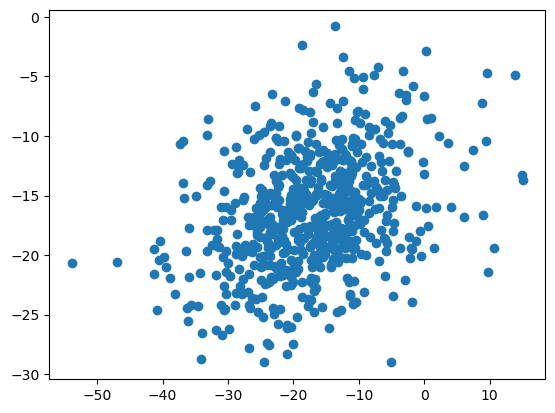

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(transport.values, t_umo_obs.dv_dz_times_X.values)

In [ ]:
from sklearn.metrics import r2_score

r2_score(t_umo_obs.dv_dz_times_X.values, transport.values)

-2.494976133393856

## Merging to the boundaries 

In [8]:
ds_argo_merged_10days, _ = load_merged_argo_dataset_and_tumo('10D', lat_bounds = lat_bounds)

def calc_merged_profiles_from_ds_argo_per_t(ds_argo_ti, compartments):
    ds_argo_ti = ds_argo_ti.sortby('lon')
    ds_argo_ti = ds_argo_ti.assign_coords(pos_i = ('pos', np.arange(ds_argo_ti.lon.shape[0])))

    compartment_profiles = []
    for compartment in compartments:
        argo_pos_mask = (ds_argo_ti.lon >= compartment[1]) & (ds_argo_ti.lon <= compartment[2]) & (ds_argo_ti.profile_mask == 1)

        if argo_pos_mask.sum() == 0:
            return None

        ds_argo_ti_comp = ds_argo_ti.where(argo_pos_mask, drop = True)
        valid_values_mask =(~ds_argo_ti_comp.temperature.isnull())

        if compartment[3] == 'west':
            westward_indices = ds_argo_ti_comp.pos_i.where(valid_values_mask).min('pos')
            westward_indices = westward_indices.fillna(westward_indices.min()).astype(int)
            merged_profile = ds_argo_ti.isel(pos = westward_indices)
        elif compartment[3] == 'east':
            eastward_indices = ds_argo_ti_comp.pos_i.where(valid_values_mask).max('pos')
            eastward_indices = eastward_indices.fillna(eastward_indices.max()).astype(int)
            merged_profile = ds_argo_ti.isel(pos = eastward_indices)
        else:
            raise ValueError('Unknown compartment direction')
        merged_profile = merged_profile.drop_vars('pos')
        compartment_profiles.append(merged_profile)

    compartment_profiles = xr.concat(compartment_profiles, dim = 'pos')
    compartment_profiles = compartment_profiles.assign_coords(pos = [c[0] for c in compartments])

    return compartment_profiles


compartments = [
    ['west_p', -76.74, -70, 'west'],
    ['mar_west_p', -60, -47, 'east'],
    ['mar_east_p', -47, -40, 'west'],
    ['east_p', -30, -13.5, 'east']
]

ds_argo_compartment_list = []
time_is_argo_compartment_list = []
for i in range(ds_argo_merged_10days.time.shape[0]):
    ds_compartment_ti = calc_merged_profiles_from_ds_argo_per_t(ds_argo_merged_10days.isel(time = i), compartments)
    
    if ds_compartment_ti is None:
        continue
    ds_argo_compartment_list.append(ds_compartment_ti)
    time_is_argo_compartment_list.append(i)
    
ds_argo_compartment_before_smooth = xr.concat(ds_argo_compartment_list, dim = 'time').assign_coords(time = ds_argo_merged_10days.time.isel(time = time_is_argo_compartment_list))

ds_argo_compartment_before_smooth['lon'] = ds_argo_compartment_before_smooth.lon.median('z')

if time_smoothing != '10D':
    ds_argo_compartment = ds_argo_compartment_before_smooth.resample(time = time_smoothing).mean()
else:
    ds_argo_compartment = ds_argo_compartment_before_smooth
ds_argo_compartment = ds_argo_compartment.where(ds_argo_compartment.profile_mask == 1, drop = True)


ds_argo_compartment

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


<xarray.Dataset>
Dimensions:       (time: 350, pos: 4, z: 242)
Coordinates:
  * time          (time) datetime64[ns] 2006-12-28 2007-01-07 ... 2021-11-29
  * z             (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0
    pressure      (z) float64 4.82e+03 4.8e+03 4.78e+03 ... 40.0 20.0 0.0
    lon           (time, pos) float64 -71.75 -52.06 -41.25 ... -40.27 -21.5
    lat           (time, pos, z) float64 25.89 25.89 25.89 ... 26.4 26.4 26.4
    time_1d       (time, pos, z) datetime64[ns] 2007-01-01 ... 2021-11-28
    pos_i         (time, pos, z) int64 1 1 1 1 1 1 1 1 ... 33 33 33 33 33 33 33
  * pos           (pos) <U10 'west_p' 'mar_west_p' 'mar_east_p' 'east_p'
Data variables:
    temperature   (time, pos, z) float64 nan nan nan nan ... 23.61 23.61 23.6
    salinity      (time, pos, z) float64 nan nan nan nan ... 37.33 37.33 37.34
    profile_mask  (time, pos, z) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    ct            (time, pos, z) float64 nan nan nan nan ... 23.52 23.52 23.52
    rho           (time, pos, z) float64 nan nan nan ... 1.025e+03 1.025e+03

In [9]:
xr.concat(ds_argo_compartment_list, dim = 'time')

<xarray.Dataset>
Dimensions:       (time: 350, pos: 4, z: 242)
Coordinates:
  * time          (time) datetime64[ns] 2006-12-28 2007-01-07 ... 2021-11-29
  * z             (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0
    pressure      (z) float64 4.82e+03 4.8e+03 4.78e+03 ... 40.0 20.0 0.0
    lon           (time, pos, z) float64 -71.75 -71.75 -71.75 ... -21.5 -21.5
    lat           (time, pos, z) float64 25.89 25.89 25.89 ... 26.4 26.4 26.4
    time_1d       (time, pos, z) datetime64[ns] 2007-01-01 ... 2021-11-28
    pos_i         (time, pos, z) int64 1 1 1 1 1 1 1 1 ... 33 33 33 33 33 33 33
  * pos           (pos) <U10 'west_p' 'mar_west_p' 'mar_east_p' 'east_p'
Data variables:
    temperature   (time, pos, z) float64 nan nan nan nan ... 23.61 23.61 23.6
    salinity      (time, pos, z) float64 nan nan nan nan ... 37.33 37.33 37.34
    profile_mask  (time, pos, z) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    ct            (time, pos, z) float64 nan nan nan nan ... 23.52 23.52 23.52
    rho           (time, pos, z) float64 nan nan nan ... 1.025e+03 1.025e+03

## Aggregated profiles


Merged to compartments: 

In [10]:
import hvplot.xarray
ds_argo_compartment.lon.isel().drop_vars('lon').hvplot( by = 'pos', subplots = False, x = 'lon', y = 'time')


:NdOverlay   [pos]
   :Curve   [lon]   (time)

Naive binning:

In [11]:
lon_bined_argos

<xarray.Dataset>
Dimensions:       (z: 242, pos: 29, time: 653)
Coordinates:
  * z             (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0
  * pos           (pos) object (-88.0, -85.31] ... (-12.69, -10.0]
  * time          (time) datetime64[ns] 2004-04-02 2004-04-12 ... 2022-02-07
    pressure      (z) float64 4.82e+03 4.8e+03 4.78e+03 ... 40.0 20.0 0.0
Data variables:
    temperature   (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan
    salinity      (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan
    profile_mask  (time, pos) float64 nan nan nan nan nan ... nan nan 1.0 nan
    ct            (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan
    rho           (time, pos, z) float64 nan nan nan nan nan ... nan nan nan nan

## Baseline 1

Use the merged product to append this to the $dvdz$ of the rapid array and calculate the tranport.

In [12]:
# Loading the dv_dz data from the rapid calculation 
dv_dz_obs = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_obs.nc')
dv_dz_obs = dv_dz_obs.resample(time = time_smoothing).mean()
dv_dz_obs

<xarray.Dataset>
Dimensions:        (z: 242, time: 653)
Coordinates:
  * z              (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0
  * time           (time) datetime64[ns] 2004-04-02 2004-04-12 ... 2022-02-07
Data variables:
    dv_dz_times_X  (time, z) float64 -1.81 -1.795 -1.728 -1.664 ... nan nan nan

In [13]:

def calc_umo_tranport(ds_pos, obs_dv_dz = None, depth_obs_concat = -1000):

    g = 9.81
    f = 2 * 7.292116E-5 * np.sin(np.deg2rad(26.5))
    rho0 = 1025.0
    zref = -4800

    rho_diff = xr.concat(
            [
                (
                    ds_pos.isel(pos=start_i + 1).rho#.squeeze(drop=True).rho
                    - ds_pos.isel(pos=start_i).rho#.squeeze(drop=True).rho
                ).assign_coords(box=f"{start_i}_{start_i+1}")
                for start_i in range(ds_pos.pos.shape[0] - 1)
            ],
            dim="box"
        )

    dv_dz = (- rho_diff * g / f / rho0).sum("box").where(
                (~(- rho_diff * g / f / rho0).isnull()).sum("box") > 0
            ).rename("dv_dz_times_X")

    if obs_dv_dz is not None:

        dv_dz = xr.where(
            (~dv_dz.where(dv_dz.z > depth_obs_concat).isnull()),
            dv_dz,
            obs_dv_dz.dv_dz_times_X.data,
        )

    # # cut the surface 
    dv_dz = dv_dz.where(dv_dz.z < -150)

    _dv_dz = dv_dz.isel(z=slice(-40, None))
    dv_dz_fillup = xr.where(
        ~dv_dz.isnull(),
        dv_dz,
        (_dv_dz.isel(z=0) + _dv_dz.diff("z").ffill("z").cumsum("z")).interp(z=dv_dz.z)
    )
    
    dv_dz = dv_dz_fillup
    
    transp_umo = (-(
            ((dv_dz.isel(z=slice(None, None, -1)).cumsum("z") * 20.0))
            - ((dv_dz.isel(z=slice(None, None, -1)).cumsum("z") * 20.0)).sel(z=zref, method="nearest")
        ).cumsum("z") * 20.0 / 1e6).sel(z=-1000, method="nearest")

    return transp_umo, dv_dz

In [14]:
def cacluate_transport_neighboring_filled_pos(ds_pos_rho, min_argo_depth):
    transports = []
    dv_dz_ts = []

    if 'time_1d' in ds_pos_rho.coords:
        ds_pos_rho = ds_pos_rho.drop_vars('time_1d')

    lon_mask_deeper_than = (~ds_pos_rho.rho.isnull()).sum('z') >= (~ds_pos_rho.z.where(ds_pos_rho.z > min_argo_depth).isnull()).sum()
    valid_times_mask = lon_mask_deeper_than.sum('pos') > 1

    ds_pos_rho = ds_pos_rho.where(valid_times_mask, drop = True)

    for i in range(ds_pos_rho.time.shape[0]):

        ds_pos_rho_t = ds_pos_rho.isel(time = i)

        lon_mask_deeper_than1000dbar = (~ds_pos_rho_t.rho.isnull()).sum('z') >= (~ds_pos_rho_t.z.where(ds_pos_rho_t.z > min_argo_depth).isnull()).sum()
        

        ds_pos_rho_t_valid = ds_pos_rho_t.where(lon_mask_deeper_than1000dbar, drop = True)
        try:
            transport, dv_dz_t = calc_umo_tranport(ds_pos_rho_t_valid, dv_dz_obs.sel(time = ds_pos_rho_t.time, method= 'nearest'), depth_obs_concat=min_argo_depth)
            # transport, dv_dz_t = calc_umo_tranport(ds_pos_rho_t_valid, None, depth_obs_concat=min_argo_depth)
        except Exception as e:
            # print the time index and raise the error
            print(i)
            raise e
        
        transports.append(transport)
        dv_dz_ts.append(dv_dz_t)


    transport = xr.concat(transports, dim = 'time').assign_coords(time = ds_pos_rho.time.isel(time = slice(None, None)))
    ds_dv_dz = xr.concat(dv_dz_ts, dim = 'time').assign_coords(time = ds_pos_rho.time.isel(time = slice(None, None)))

    return transport, ds_dv_dz

In [15]:
t_binned_argo_1000, dv_dz_binned_argo_1000 = cacluate_transport_neighboring_filled_pos(lon_bined_argos, -1000)
t_binned_argo_2000, dv_dz_binned_argo_2000 = cacluate_transport_neighboring_filled_pos(lon_bined_argos, -2000)

In [16]:
t_merged_argo_1000, dv_dz_merged_argo_1000 = cacluate_transport_neighboring_filled_pos(ds_argo_compartment, -1000)
t_merged_argo_2000, dv_dz_merged_argo_2000 = cacluate_transport_neighboring_filled_pos(ds_argo_compartment, -2000)

In [17]:
(
    (
        t_binned_argo_1000.hvplot(label = 'argo_1000dbar')
        * t_binned_argo_2000.hvplot(label = 'argo_2000dbar')
        * t_umo_obs.hvplot(label = 'rapid')
    )
    +
     (
        t_merged_argo_1000.hvplot(label = 'merged_1000dbar', color = 'gray')
        * t_merged_argo_2000.hvplot(label = 'merged_2000dbar', color = 'gray', line_dash = 'dashed')
        * t_umo_obs.hvplot(label = 'rapid')
    )
    # + (
    #     dv_dz_binned_argo_1000.mean('time').hvplot(x = 'z', y = 'dv_dz_times_X', label = 'argo_1000dbar')
    #     * dv_dz_binned_argo_2000.mean('time').hvplot(x = 'z', y = 'dv_dz_times_X', label = 'argo_2000dbar')
    #     * dv_dz_obs.mean('time').hvplot(x = 'z', y = 'dv_dz_times_X', label = 'obs')
    
    # )
    # + (
    #     (t_merged_argo_1000 - t_binned_argo_1000).hvplot(label = 'merged-binned_1000dbar')
    #     * (t_merged_argo_2000 - t_binned_argo_2000).hvplot(label = 'merged-binned_2000dbar')
        
    # )
).cols(1).opts(title = f'For {time_smoothing} as smoothing')


:Layout
   .Overlay.I  :Overlay
      .Curve.Argo_1000dbar :Curve   [time]   (dv_dz_times_X)
      .Curve.Argo_2000dbar :Curve   [time]   (dv_dz_times_X)
      .Curve.Rapid         :Curve   [time]   (dv_dz_times_X)
   .Overlay.II :Overlay
      .Curve.Merged_1000dbar :Curve   [time]   (dv_dz_times_X)
      .Curve.Merged_2000dbar :Curve   [time]   (dv_dz_times_X)
      .Curve.Rapid           :Curve   [time]   (dv_dz_times_X)

In [18]:
(
    (
        dv_dz_binned_argo_1000.mean('time').hvplot(x = 'z', y = 'dv_dz_times_X', label = 'argo_1000dbar')
        * dv_dz_binned_argo_2000.mean('time').hvplot(x = 'z', y = 'dv_dz_times_X', label = 'argo_2000dbar')
        * dv_dz_obs.mean('time').hvplot(x = 'z', y = 'dv_dz_times_X', label = 'obs')
    )
    + (
        dv_dz_merged_argo_1000.mean('time').hvplot(x = 'z', y = 'dv_dz_times_X', label = 'merged_1000dbar')
        * dv_dz_merged_argo_2000.mean('time').hvplot(x = 'z', y = 'dv_dz_times_X', label = 'merged_2000dbar')
        * dv_dz_obs.mean('time').hvplot(x = 'z', y = 'dv_dz_times_X', label = 'obs')
    )
).cols(1)

:Layout
   .Overlay.I  :Overlay
      .Curve.Argo_1000dbar :Curve   [z]   (dv_dz_times_X)
      .Curve.Argo_2000dbar :Curve   [z]   (dv_dz_times_X)
      .Curve.Obs           :Curve   [z]   (dv_dz_times_X)
   .Overlay.II :Overlay
      .Curve.Merged_1000dbar :Curve   [z]   (dv_dz_times_X)
      .Curve.Merged_2000dbar :Curve   [z]   (dv_dz_times_X)
      .Curve.Obs             :Curve   [z]   (dv_dz_times_X)

In [19]:
# Print the R2 score for the 1000 dbar and 2000 dbar transport to the rapid calculation
# For this make a fancy format in form of a table
from sklearn.metrics import r2_score, mean_absolute_error

print('R2 score for the 1000 dbar transport')
print('-------------------------------------')
print(f'Binned: {r2_score(t_umo_obs.sel(time = t_binned_argo_1000.time, method = "nearest").dv_dz_times_X.values, t_binned_argo_1000.values)}')
print(f'Merged: {r2_score(t_umo_obs.sel(time = t_merged_argo_1000.time, method = "nearest").dv_dz_times_X.values, t_merged_argo_1000.values)}')
print('-------------------------------------')
print('R2 score for the 2000 dbar transport')
print('-------------------------------------')
print(f'Binned: {r2_score(t_umo_obs.sel(time = t_binned_argo_2000.time, method = "nearest").dv_dz_times_X.values, t_binned_argo_2000.values)}')
print(f'Merged: {r2_score(t_umo_obs.sel(time = t_merged_argo_2000.time, method = "nearest").dv_dz_times_X.values, t_merged_argo_2000.values)}')
print('-------------------------------------')
print('MAE score for the 1000 dbar transport')
print('-------------------------------------')
print(f'Binned: {mean_absolute_error(t_umo_obs.sel(time = t_binned_argo_1000.time, method = "nearest").dv_dz_times_X.values, t_binned_argo_1000.values):.2f} Sv')
print(f'Merged: {mean_absolute_error(t_umo_obs.sel(time = t_merged_argo_1000.time, method = "nearest").dv_dz_times_X.values, t_merged_argo_1000.values):.2f} Sv')
print('-------------------------------------')
print('MAE score for the 2000 dbar transport')
print('-------------------------------------')
print(f'Binned: {mean_absolute_error(t_umo_obs.sel(time = t_binned_argo_2000.time, method = "nearest").dv_dz_times_X.values, t_binned_argo_2000.values):.2f} Sv')
print(f'Merged: {mean_absolute_error(t_umo_obs.sel(time = t_merged_argo_2000.time, method = "nearest").dv_dz_times_X.values, t_merged_argo_2000.values):.2f} Sv')

R2 score for the 1000 dbar transport
-------------------------------------
Binned: -2.2201472965952607
Merged: -1.0723896442958183
-------------------------------------
R2 score for the 2000 dbar transport
-------------------------------------
Binned: -4.38651456356586
Merged: -2.6397737248388315
-------------------------------------
MAE score for the 1000 dbar transport
-------------------------------------
Binned: 6.63 Sv
Merged: 5.19 Sv
-------------------------------------
MAE score for the 2000 dbar transport
-------------------------------------
Binned: 8.81 Sv
Merged: 6.67 Sv


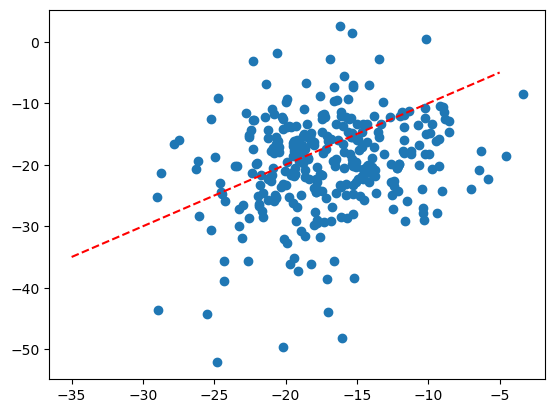

In [20]:
import matplotlib.pyplot as plt
plt.scatter(t_umo_obs.sel(time = t_merged_argo_2000.time, method = "nearest").dv_dz_times_X.values, t_merged_argo_2000.values)

plt.plot([-35, -5], [-35, -5], 'r--')

## Baseline 2

In [125]:
input_X = ds_argo_compartment

In [126]:


# standardize the rho values at the bins
from copy import deepcopy
input_X

<xarray.Dataset>
Dimensions:       (time: 360, pos: 4, z: 242)
Coordinates:
  * time          (time) datetime64[ns] 2006-12-28 2007-01-07 ... 2021-11-29
  * z             (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0
    pressure      (z) float64 4.82e+03 4.8e+03 4.78e+03 ... 40.0 20.0 0.0
    lon           (time, pos) float64 -72.33 -52.5 -41.25 ... -40.27 -21.46
    lat           (time, pos, z) float64 26.46 26.46 26.46 ... 26.33 26.33 26.33
    pos_i         (time, pos, z) int64 1 1 1 1 1 1 1 1 ... 44 44 44 44 44 44 44
  * pos           (pos) <U10 'west_p' 'mar_west_p' 'mar_east_p' 'east_p'
Data variables:
    temperature   (time, pos, z) float64 nan nan nan nan ... 22.73 22.72 22.7
    salinity      (time, pos, z) float64 nan nan nan nan ... 37.33 37.29 37.29
    profile_mask  (time, pos, z) float64 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    ct            (time, pos, z) float64 nan nan nan nan ... 22.65 22.64 22.63
    rho           (time, pos, z) float64 nan nan nan ... 1.026e+03 1.026e+03

In [127]:
dv_dz_obs = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_obs.nc')
dv_dz_obs = dv_dz_obs.resample(time = time_smoothing).mean()


_dv_dz = dv_dz_obs.isel(z=slice(-40, None)).dv_dz_times_X
dv_dz_obs_fillup = xr.where(
    ~dv_dz_obs.isnull(),
    dv_dz_obs,
    (_dv_dz.isel(z=0) + _dv_dz.diff("z").ffill("z").cumsum("z")).interp(z=dv_dz_obs.z)
)
target_y = dv_dz_obs_fillup.dv_dz_times_X
target_y = target_y.sel(time = input_X.time, method = 'nearest')

valid_ts_mask = target_y.isnull().sum('z') == 0
target_y = target_y.where(valid_ts_mask, drop = True)
input_X = input_X.isel(time = valid_ts_mask.data)


In [128]:
permute = False
train_ratio = .75
if permute: 
    blocks_permuted_indices = np.concatenate([np.arange(starti, min(starti+12, input_X.time.shape[0])) for starti in np.random.permutation(np.arange(0, input_X.time.shape[0], 12))])
else :
    blocks_permuted_indices = np.arange(input_X.time.shape[0])


train_indices = blocks_permuted_indices[:int( train_ratio * blocks_permuted_indices.shape[0])]
test_indices = blocks_permuted_indices[int(train_ratio * blocks_permuted_indices.shape[0]):]

In [129]:

rho_mean = input_X.rho.isel(time = train_indices).mean(['time', 'pos'])
rho_std = input_X.rho.isel(time = train_indices).std(['time', 'pos', 'z'])

def standardize_rho(ds_pos, rho_mean=None, rho_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["rho"] = (ds_pos["rho"] - rho_mean) / rho_std
    return ds_pos

input_X_std = standardize_rho(
    input_X,
    rho_mean=rho_mean, 
    rho_std=rho_std,
)

input_X_std = input_X_std.fillna(0)
input_X_std = input_X_std.rho.stack(feature = ('pos', 'z'))

In [130]:

train_X = input_X_std.values[train_indices]
test_X = input_X_std.values[test_indices]

train_y = target_y.values[train_indices]
test_y = target_y.values[test_indices]

In [131]:
mean_per_z = np.mean(train_y, axis = 0)
std_per_z = np.std(train_y, axis = 0)

train_y_scaled = (train_y - mean_per_z) / std_per_z
test_y_scaled = (test_y - mean_per_z) / std_per_z

In [132]:
from sklearn.linear_model import Lasso, MultiTaskLassoCV, Ridge, RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, DotProduct

In [164]:
# regressor = Lasso(alpha=.1).fit(train_X, train_y)
# regressor = Ridge(alpha=.68).fit(train_X, train_y_scaled)
regressor = RidgeCV(alphas=[.01, .05,.08,.1, .15,.3, .5, 1, 5, 10]).fit(train_X, train_y_scaled)
# regressor = GaussianProcessRegressor(DotProduct() + WhiteKernel()).fit(train_X, train_y)
# regressor = MLPRegressor(hidden_layer_sizes=(1024,1024, 512), max_iter=1000, alpha=.001,
#                     solver='adam', verbose=10,  random_state=21,tol=0.000000001, learning_rate_init=1e-3, learning_rate='adaptive', validation_fraction=.1, early_stopping=True, n_iter_no_change=40).fit(train_X, train_y_scaled)

In [165]:
regressor.score(test_X, test_y_scaled)#, regressor.alpha_

-2.0214458085691756

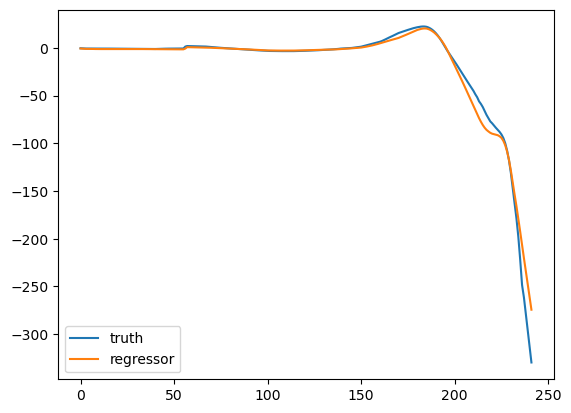

In [166]:
import matplotlib.pyplot as plt
i = 3

plt.plot(test_y[i], label = 'truth')
plt.plot(((regressor.predict(test_X) * std_per_z) + mean_per_z)[i], label = 'regressor')
plt.legend()

In [167]:

def prediction_to_tranport(prediction, time_array, z_array ):

    dv_dz_prediction = xr.DataArray(
        prediction,
        dims = ['time', 'z'],
        coords = {
            'time': time_array,
            'z': z_array
        }
    ).rename('dv_dz_times_X')

    transp_umo_prediction = (-(
        ((dv_dz_prediction.isel(z=slice(None, None, -1)).cumsum("z") * 20.0))
        - ((dv_dz_prediction.isel(z=slice(None, None, -1)).cumsum("z") * 20.0)).sel(z=-4800, method="nearest")
    ).cumsum("z") * 20.0 / 1e6).sel(z=-1000, method="nearest")

    return transp_umo_prediction


In [168]:
test_predictions = regressor.predict(test_X)
test_predictions = (test_predictions * std_per_z) + mean_per_z
transp_umo_prediction = prediction_to_tranport(test_predictions, target_y.time.isel(time = test_indices), target_y.z)


In [169]:
(
    transp_umo_prediction.hvplot(label = 'LR')
    * t_umo_obs.sel(time = transp_umo_prediction.time, method = 'nearest').hvplot(label = 'rapid')
    # * t_merged_argo_2000.sel(time = transp_umo_prediction.time, method = 'nearest').hvplot(label = 'merged_2000dbar')
)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Overlay
   .Curve.LR    :Curve   [time]   (dv_dz_times_X)
   .Curve.Rapid :Curve   [time]   (dv_dz_times_X)

In [170]:
# calc R2 score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [171]:
print(f'R2: {r2_score(t_umo_obs.sel(time = transp_umo_prediction.time, method = "nearest").dv_dz_times_X.values, transp_umo_prediction.values)}')
print(f'MAE: {mean_absolute_error(t_umo_obs.sel(time = transp_umo_prediction.time, method = "nearest").dv_dz_times_X.values, transp_umo_prediction.values)}')
print(f'MSE: {mean_squared_error(t_umo_obs.sel(time = transp_umo_prediction.time, method = "nearest").dv_dz_times_X.values, transp_umo_prediction.values)}')

R2: -0.9384577988244593
MAE: 4.705119808206555
MSE: 44.45788782023132


## Baseline 4

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
dv_dz_obs = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_obs.nc')
dv_dz_obs = dv_dz_obs.resample(time = time_smoothing).mean()


_dv_dz = dv_dz_obs.isel(z=slice(-40, None)).dv_dz_times_X
dv_dz_obs_fillup = xr.where(
    ~dv_dz_obs.isnull(),
    dv_dz_obs,
    (_dv_dz.isel(z=0) + _dv_dz.diff("z").ffill("z").cumsum("z")).interp(z=dv_dz_obs.z)
)
target_y = dv_dz_obs_fillup.dv_dz_times_X
target_y = target_y.sel(time = input_X.time, method = 'nearest')

valid_ts_mask = target_y.isnull().sum('z') == 0
target_y = target_y.where(valid_ts_mask, drop = True)

In [ ]:
pca = PCA(n_components=15).fit(train_y)

(array([ 9., 14., 43., 60., 62., 73., 49., 12.,  6.,  4.]),
 array([-46.39211534, -36.32379483, -26.25547432, -16.1871538 ,
         -6.11883329,   3.94948722,  14.01780773,  24.08612824,
         34.15444876,  44.22276927,  54.29108978]),
 <BarContainer object of 10 artists>)

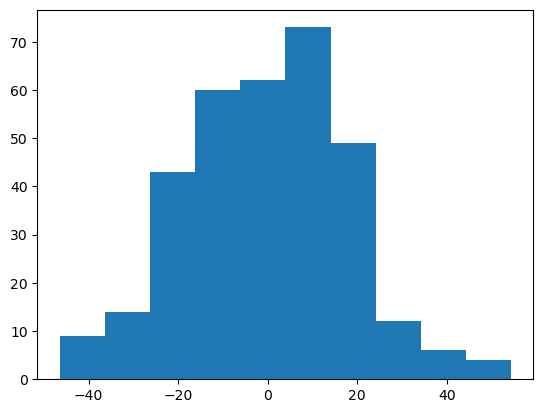

In [ ]:
plt.hist(pca.transform(target_y.values)[:, 4])

In [ ]:

regressor = Ridge(alpha=01.4).fit(train_X, pca.transform(train_y))


# regressor = MLPRegressor(hidden_layer_sizes=(1024,512, 32), max_iter=1000, alpha=.001,
#                     solver='adam', verbose=10,  random_state=21,tol=0.000000001, learning_rate_init=1e-3, learning_rate='adaptive', validation_fraction=.1, early_stopping=True, n_iter_no_change=40).fit(train_X, pca.transform(train_y))

In [ ]:
regressor.score(test_X, pca.transform(test_y))

-0.38743108695739764

In [ ]:
test_predictions = regressor.predict(test_X)

test_predictions = pca.inverse_transform(test_predictions)

transp_umo_prediction = prediction_to_tranport(test_predictions, target_y.time.isel(time = test_indices), target_y.z)


In [ ]:
(
    transp_umo_prediction.hvplot(label = 'LR')
    * t_umo_obs.sel(time = transp_umo_prediction.time, method = 'nearest').hvplot(label = 'rapid')
)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Overlay
   .Curve.LR    :Curve   [time]   (dv_dz_times_X)
   .Curve.Rapid :Curve   [time]   (dv_dz_times_X)

In [ ]:
print(f'R2: {r2_score(t_umo_obs.sel(time = transp_umo_prediction.time, method = "nearest").dv_dz_times_X.values, transp_umo_prediction.values)}')
print(f'MAE: {mean_absolute_error(t_umo_obs.sel(time = transp_umo_prediction.time, method = "nearest").dv_dz_times_X.values, transp_umo_prediction.values)}')


R2: 0.0005035802758012187
MAE: 3.6043157621328445


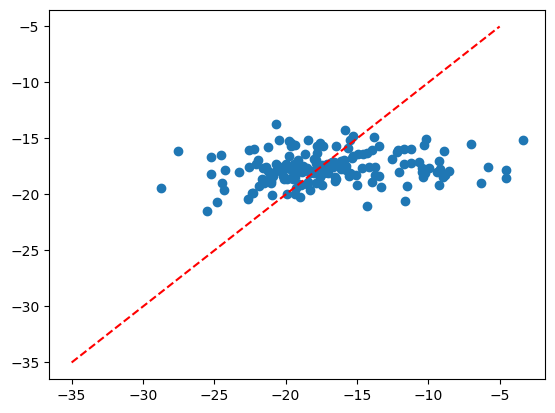

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(t_umo_obs.sel(time = transp_umo_prediction.time, method = "nearest").dv_dz_times_X.values, transp_umo_prediction.values)

plt.plot([-35, -5], [-35, -5], 'r--')

## DvDvz -> DvDz

In [95]:
dv_dz_obs = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_obs.nc')
dv_dz_obs = dv_dz_obs.resample(time = time_smoothing).mean()

dv_dz_target = dv_dz_obs.dv_dz_times_X
_dv_dz = dv_dz_target.isel(z=slice(-40, None))
dv_dz_fillup = xr.where(
    ~dv_dz_target.isnull(),
    dv_dz_target,
    (_dv_dz.isel(z=0) + _dv_dz.diff("z").ffill("z").cumsum("z")).interp(z=dv_dz_target.z)
)
dv_dz_target = dv_dz_fillup

dv_dz_target = dv_dz_target.sel(time = dv_dz_merged_argo_2000.time, method = 'nearest')

valid_ts_mask = dv_dz_target.isnull().sum('z') == 0

dv_dz_target = dv_dz_target.where(valid_ts_mask, drop = True)
dv_dz_merged_argo_2000 = dv_dz_merged_argo_2000.sel(time = dv_dz_target.time)

In [96]:
"""
This cell performs data manipulation on the input_data and longitudal_bounds variables.
It renames the 'z' dimension of input_data to 'f' and drops the 'pressure' variable.
It also renames the 'pos' dimension of longitudal_bounds to 'f' and drops the 'lon' variable.
Finally, it concatenates input_data and longitudal_bounds along the 'f' dimension.
"""

input_data = dv_dz_merged_argo_2000#.where(dv_dz_merged_argo_2000.z > -2000, drop = True)

longitudal_bounds = ds_argo_compartment.sel(time = input_data.time).lon
month = ds_argo_compartment.sel(time = input_data.time).time.dt.month.expand_dims('f', 1).assign_coords(f = [0])

# concat the inputdata with dimensions (time, z) with the longitudal bounds (time, pos) along a new dimension 'f' which consists of z and pos
input_data = input_data.rename(z = 'f' ).drop_vars('pressure')
longitudal_bounds = longitudal_bounds.rename(pos = 'f').drop_vars('lon')
input_data = xr.concat([input_data, longitudal_bounds], dim = 'f')


input_data

<xarray.DataArray 'dv_dz_times_X' (time: 296, f: 246)>
array([[ -0.71771532,  -0.83407093,  -0.95356191, ..., -58.45499039,
        -43.72700119, -16.89699936],
       [ -1.02165646,  -1.13814215,  -1.25775345, ..., -57.73099136,
        -43.69800186, -16.74500084],
       [ -1.78208066,  -1.82377626,  -1.86759728, ..., -56.06900024,
        -43.03099823, -15.95300007],
       ...,
       [ -2.1705101 ,  -2.20675184,  -2.24518042, ..., -54.55065155,
        -46.77994156, -16.91500092],
       [ -1.91936643,  -1.96484149,  -2.00842857, ..., -55.157341  ,
        -46.4311409 , -17.53899956],
       [ -1.84362215,  -1.93519516,  -2.01161543, ..., -59.26670074,
        -45.95901871, -17.89800072]])
Coordinates:
  * time     (time) datetime64[ns] 2010-03-02 2010-03-12 ... 2020-12-14
  * f        (f) <U32 '-4820.0' '-4800.0' '-4780.0' ... 'mar_east_p' 'east_p'

In [97]:
train_ratio = .75
val_percentage_of_train = .2

indices = np.arange(input_data.time.shape[0])
# np.random.shuffle(indices)

train_indices = indices[:int((1 - val_percentage_of_train)*train_ratio * indices.shape[0])]
val_indices = indices[int(train_ratio * indices.shape[0]) -int(val_percentage_of_train*train_ratio * indices.shape[0]) :int(train_ratio * indices.shape[0])]
test_indices = indices[int(train_ratio * indices.shape[0]):]


train_X = input_data.isel(time = train_indices).values
val_X = input_data.isel(time = val_indices).values
test_X = input_data.isel(time = test_indices).values


mean_dvdz_merged = np.mean(train_X, axis = 0)
std_dvdz_merged = np.std(train_X, axis = 0)

train_X_scaled = (train_X - mean_dvdz_merged) / std_dvdz_merged
val_X_scaled = (val_X - mean_dvdz_merged) / std_dvdz_merged
test_X_scaled = (test_X - mean_dvdz_merged) / std_dvdz_merged

train_y = dv_dz_target.isel(time = train_indices).values
val_y = dv_dz_target.isel(time = val_indices).values
test_y = dv_dz_target.isel(time = test_indices).values

mean_per_z = np.mean(train_y, axis = 0)
std_per_z = np.std(train_y, axis = 0)

train_y_scaled = (train_y - mean_per_z) / std_per_z
val_y_scaled = (val_y - mean_per_z) / std_per_z
test_y_scaled = (test_y - mean_per_z) / std_per_z



In [98]:
from sklearn.linear_model import Ridge, RidgeCV, MultiTaskLassoCV

regressor = RidgeCV(alphas=[.01, .05,.08,.1, .15,.3, .5, 1, 5, 10, 15, 20, 25, 50, 100, 150,200,250,500,1000]).fit(train_X_scaled, train_y_scaled)
# regressor = MultiTaskLassoCV(alphas=[.01, .05,.08,.1, .15,.3, .5, 1, 5, 10, 15, 20, 25, 50, 100, 150,200,250,500,1000]).fit(train_X_scaled, train_y_scaled)
# regressor = MultiTaskLassoCV(alphas=[.1]).fit(train_X_scaled, train_y_scaled)

In [99]:
regressor.score(test_X_scaled, test_y_scaled), regressor.alpha_

(0.3713538399139652, 25.0)

In [100]:
test_predictions = regressor.predict(test_X_scaled)

test_predictions = (test_predictions * std_per_z) + mean_per_z

transport = prediction_to_tranport(test_predictions, dv_dz_target.time.isel(time = test_indices), dv_dz_target.z)

(
    transport.hvplot(label = 'LR')
    * t_umo_obs.sel(time = transport.time, method = 'nearest').hvplot(label = 'rapid')
)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Overlay
   .Curve.LR    :Curve   [time]   (dv_dz_times_X)
   .Curve.Rapid :Curve   [time]   (dv_dz_times_X)

In [101]:
from sklearn.metrics import r2_score, mean_absolute_error
print(f'R2: {r2_score(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')
print(f'MAE: {mean_absolute_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')


R2: -0.27534776411273554
MAE: 4.0828090765703555


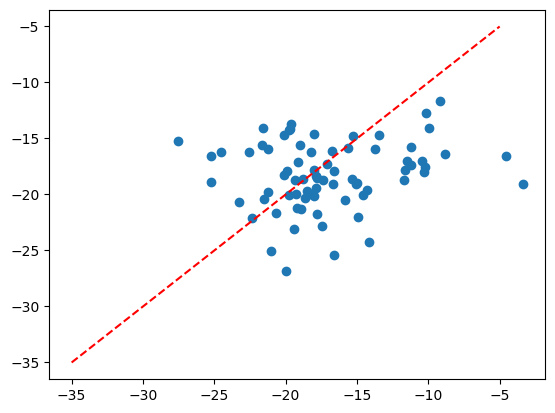

In [102]:
import matplotlib.pyplot as plt
plt.scatter(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)

plt.plot([-35, -5], [-35, -5], 'r--')

### Pytorch 

In [103]:
import torch 
from torch.utils.data import DataLoader, TensorDataset

In [104]:



dl = DataLoader(TensorDataset(torch.tensor(train_X_scaled), torch.tensor(train_y_scaled)), batch_size=8, shuffle=True)

In [105]:
## Training the fully connected neural network
from copy import deepcopy
import torch.nn as nn
import torch.optim as optim

n_features = train_X_scaled.shape[-1] 

class PredictionToTransportModel(nn.Module):

    def __init__(self,  mean_per_z, std_per_z):
        super(PredictionToTransportModel, self).__init__()
    
        self.mean_per_z = torch.tensor(mean_per_z).float()
        self.std_per_z = torch.tensor(std_per_z).float()
        self.bottom_index = np.argmin(np.abs(dv_dz_target.z - -4800).values)
        self.amoc_index = np.argmin(np.abs(dv_dz_target.z - -1000).values)

    def forward(self, x):
        x = x * self.std_per_z + self.mean_per_z

        dv_dz_prediction = x

        return (
            -((torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20) -
            (torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20).flip(-1)[:, [self.bottom_index]]).cumsum(-1) * 20 / 1e6
        ).flip(-1)[:, self.amoc_index]

class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(n_features, 16)
        self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(  16, 16)
        self.fc4 = nn.Linear(16, 242)

        self.dropout1 = nn.Dropout(p=.2)
        self.dropout2 = nn.Dropout(p=.5)

        self.input_mask = torch.rand(1, n_features) > .00
        self.transformer = PredictionToTransportModel(mean_per_z, std_per_z)


    def forward(self, x):
        x = x * self.input_mask.bool()
        x = torch.relu(self.fc1(x))
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        # x = torch.relu(self.fc3(x))
        x = self.fc4(x)

        return self.transformer(x)
    
class Net_cnn(nn.Module):

    def __init__(self):
        super(Net_cnn, self).__init__()

        self.cnn1 = nn.Conv1d(1, 4, 3)
        self.maxpool1 = nn.MaxPool1d(2)
        self.cnn2 = nn.Conv1d(4, 8, 3)
        self.maxpool2 = nn.MaxPool1d(2)
        self.fc1 = nn.Linear(184, 128)
        # self.fc1 = nn.Linear(lag*100, 128)
        self.fc2 = nn.Linear(128, 32)
        self.fc3 = nn.Linear(32, 64)
        self.fc4 = nn.Linear(64, 242)

        self.input_mask = torch.randn(1, n_features) > .4

        self.transformer = PredictionToTransportModel(mean_per_z, std_per_z)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.cnn1(x)
        x = torch.relu(x)
        x = self.maxpool1(x)
        x = self.cnn2(x)
        x = torch.relu(x)
        x = self.maxpool2(x)
        x = x.view(x.size(0), -1)
        
        x = torch.relu(self.fc1(x))
        x = nn.functional.dropout(x, p=.5)
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = nn.functional.dropout(x, p=.2)
        x = self.fc4(x)
        return self.transformer(x)

nets = []

transformer = PredictionToTransportModel(mean_per_z, std_per_z)

for i in range(5):
    net = Net()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(net.parameters(), lr=0.005, weight_decay=1e-4)

    best_val_loss = 1e10
    best_model = None

    for epoch in range(500):  # loop over the dataset multiple times

        net.train()
        loss_per_epoch = 0.0
        for i, data in enumerate(dl, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            transport = transformer(labels).detach().float()

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs.float())
            loss = criterion(outputs, transport)
            loss.backward()
            optimizer.step()

            # print statistics
            loss_per_epoch += loss.item()

        net.eval()
        val_prediction = net(torch.tensor(val_X_scaled).float()).detach()
        val_loss = criterion(transformer(torch.tensor(val_y_scaled)).float(), val_prediction).item()

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model = deepcopy(net)

        if (epoch+1) % 50 == 0:
            print(f'Epoch {epoch}, Loss: {loss_per_epoch / len(dl)}, Val loss: {val_loss}')
    nets.append(best_model)

class EnsembleNet(nn.Module):
    def __init__(self, nets):
        super(EnsembleNet, self).__init__()
        self.nets = nn.ModuleList(nets)

    def forward(self, x):
        outputs = torch.stack([net(x) for net in self.nets])
        return torch.mean(outputs, dim=0)

net = EnsembleNet(nets)
print('Finished Training')


Epoch 49, Loss: 1.625182644828506, Val loss: 33.81169128417969
Epoch 99, Loss: 1.2833826697391013, Val loss: 31.925390243530273
Epoch 149, Loss: 0.1916911080479622, Val loss: 34.2674446105957
Epoch 199, Loss: 0.5986747741699219, Val loss: 30.909046173095703
Epoch 249, Loss: 0.8360688148633294, Val loss: 29.12615203857422
Epoch 299, Loss: 2.3963610005119573, Val loss: 33.56229019165039
Epoch 349, Loss: 1.6202990263700485, Val loss: 36.60343551635742
Epoch 399, Loss: 0.5831062119940053, Val loss: 25.288616180419922
Epoch 449, Loss: 0.17068104101749865, Val loss: 29.17820930480957
Epoch 499, Loss: 1.2673115898733553, Val loss: 35.49363708496094
Epoch 49, Loss: 1.8598713926647021, Val loss: 26.07378578186035
Epoch 99, Loss: 2.3855908286312353, Val loss: 34.02775573730469
Epoch 149, Loss: 1.001403502406269, Val loss: 29.390867233276367
Epoch 199, Loss: 0.5842217389980088, Val loss: 28.983848571777344
Epoch 249, Loss: 1.1004848399240037, Val loss: 29.91693687438965
Epoch 299, Loss: 0.2924719

In [106]:
test_predictions = net(torch.tensor(test_X_scaled).float()).detach().numpy()
transport = xr.DataArray(
    test_predictions,
    coords={
        'time':dv_dz_target.time.isel(time = test_indices)
    }, name='dv_dz_times_X')
(   
    transport.hvplot(label = 'NN')
        * t_umo_obs.sel(time = transport.time, method = 'nearest').hvplot(label = 'rapid')
)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Overlay
   .Curve.NN    :Curve   [time]   (dv_dz_times_X)
   .Curve.Rapid :Curve   [time]   (dv_dz_times_X)

In [349]:
colors = np.abs(transport - t_umo_obs.sel(time = transport.time, method = 'nearest'))
# ds_argo_compartment.lon.sel(time = colors.time).drop_vars('lon').hvplot.scatter( by = 'pos', subplots = False, x = 'lon', y = 'time')
(   
    ds_argo_compartment.lon.sel(time = colors.time).isel(pos = 0).drop_vars('lon').hvplot.scatter(c = colors.dv_dz_times_X.values, cmap = 'viridis') *
    ds_argo_compartment.lon.sel(time = colors.time).isel(pos = 1).drop_vars('lon').hvplot.scatter(c = colors.dv_dz_times_X.values, cmap = 'viridis') *
    ds_argo_compartment.lon.sel(time = colors.time).isel(pos = 2).drop_vars('lon').hvplot.scatter(c = colors.dv_dz_times_X.values, cmap = 'viridis') *
    ds_argo_compartment.lon.sel(time = colors.time).isel(pos = 3).drop_vars('lon').hvplot.scatter(c = colors.dv_dz_times_X.values, cmap = 'viridis') 
)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/holoviews/core/data/pandas.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return dataset.data.dtypes[idx].type


:Overlay
   .Scatter.I   :Scatter   [time]   (lon,_color)
   .Scatter.II  :Scatter   [time]   (lon,_color)
   .Scatter.III :Scatter   [time]   (lon,_color)
   .Scatter.IV  :Scatter   [time]   (lon,_color)

In [350]:

def create_prediction_figure(input_data, indices):

    test_predictions = net(torch.tensor(input_data).float()).detach().numpy()

    test_predictions = (test_predictions * std_per_z) + mean_per_z

    transport = prediction_to_tranport(test_predictions, dv_dz_target.time.isel(time = indices), dv_dz_target.z)

    return     (
        transport.hvplot(label = 'NN')
        * t_umo_obs.sel(time = transport.time, method = 'nearest').hvplot(label = 'rapid')
    )

create_prediction_figure(test_X_scaled, test_indices)

ValueError: operands could not be broadcast together with shapes (74,) (242,) 

In [107]:

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
print(f'R2: {r2_score(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')
print(f'MAE: {mean_absolute_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')
print(f'MSE: {mean_squared_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')



R2: -0.2078970254606478
MAE: 3.8363473371968477
MSE: 25.564186520615603


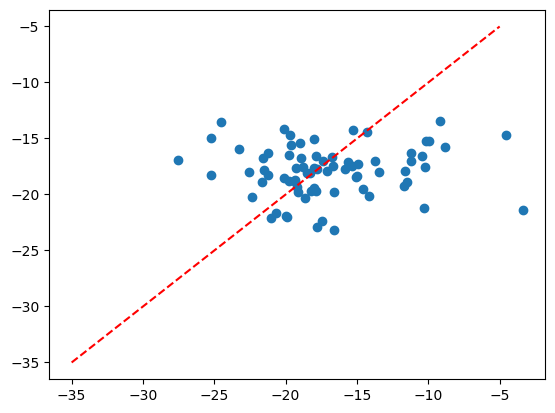

In [108]:
import matplotlib.pyplot as plt
plt.scatter(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)

plt.plot([-35, -5], [-35, -5], 'r--')


[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 296 samples in 0.000s...
[t-SNE] Computed neighbors for 296 samples in 0.010s...
[t-SNE] Computed conditional probabilities for sample 296 / 296
[t-SNE] Mean sigma: 74.477121
[t-SNE] KL divergence after 250 iterations with early exaggeration: 49.459080
[t-SNE] KL divergence after 300 iterations: 0.330556


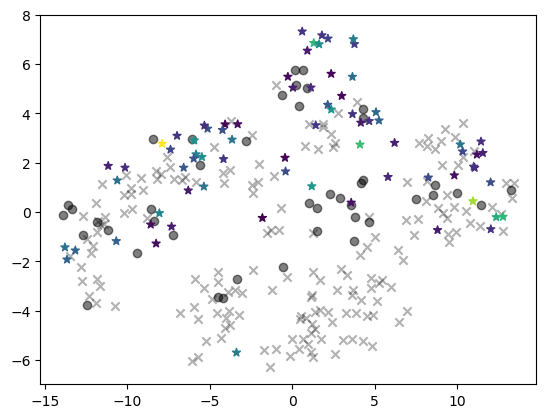

In [353]:
# import tsne
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)

mapped = tsne.fit_transform(input_data.values)


plt.scatter(mapped[train_indices, 0], mapped[train_indices, 1], marker='x', c = 'black', alpha= .3)
plt.scatter(mapped[val_indices, 0], mapped[val_indices, 1], marker='o', c = 'black', alpha= .5)
plt.scatter(mapped[test_indices, 0], mapped[test_indices, 1], marker='*', c = colors.dv_dz_times_X.values,)

## Single Profile Processing

We will load the ds_argo_merged dataset as thre base where each prfoile in the ten day window is present.
THen we will create 4 embedding one for each of the moorings and each profile is assigned by distance to those emebeddings. 
Each profile will create based on the currtent state and its rho values a delta that will be added to the embedding.

In [114]:
time_smoothing = '90D'

In [115]:
dv_dz_obs = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_obs.nc')
dv_dz_obs = dv_dz_obs.resample(time = time_smoothing).mean()
dv_dz_obs.mean('time').dv_dz_times_X#.interpolate_na('z')

<xarray.DataArray 'dv_dz_times_X' (z: 242)>
array([-1.04154792e+00, -1.14007678e+00, -1.19780916e+00, -1.25046836e+00,
       -1.25989848e+00, -1.27974539e+00, -1.29838065e+00, -1.34384821e+00,
       -1.35347114e+00, -1.36500260e+00, -1.35763074e+00, -1.31870951e+00,
       -1.30208943e+00, -1.28942966e+00, -1.28177594e+00, -1.27464587e+00,
       -1.26751882e+00, -1.26296666e+00, -1.25949297e+00, -1.25570614e+00,
       -1.25313805e+00, -1.25136263e+00, -1.25552434e+00, -1.25566955e+00,
       -1.26078892e+00, -1.26639506e+00, -1.27293171e+00, -1.27861524e+00,
       -1.28443035e+00, -1.29198713e+00, -1.30398508e+00, -1.31770378e+00,
       -1.33198247e+00, -1.34763661e+00, -1.36170676e+00, -1.37224499e+00,
       -1.35607981e+00, -1.34109211e+00, -1.32944799e+00, -1.32532422e+00,
       -1.32636166e+00, -1.32006019e+00, -1.31058376e+00, -1.29922941e+00,
       -1.28314365e+00, -1.26289971e+00, -1.24549198e+00, -1.24155295e+00,
       -1.24305826e+00, -1.24287348e+00, -1.23891364e+00, -1.23040463e+00,
       -1.21859811e+00, -1.20420088e+00, -1.18645245e+00, -1.16413471e+00,
       -4.15276171e-02,  9.74286952e-01,  9.33149842e-01,  8.94516532e-01,
        8.58475352e-01,  8.26869073e-01,  7.98770521e-01,  7.72858149e-01,
        7.45738812e-01,  7.10567718e-01,  6.74648341e-01,  6.29551306e-01,
        5.64147615e-01,  4.90890643e-01,  4.04307229e-01,  3.13326128e-01,
        2.16255914e-01,  1.62873234e-01,  4.38720255e-02, -7.80091928e-02,
       -1.99135631e-01, -3.23529809e-01, -4.50948533e-01, -5.78672666e-01,
...
        7.16824933e+00,  7.80588532e+00,  8.44736718e+00,  9.10414955e+00,
        9.77774609e+00,  1.04689210e+01,  1.12222929e+01,  1.21221513e+01,
        1.30602983e+01,  1.40272998e+01,  1.50264917e+01,  1.60410774e+01,
        1.70586391e+01,  1.81024223e+01,  1.91428225e+01,  2.01817918e+01,
        2.11703265e+01,  2.19621110e+01,  2.26201431e+01,  2.31891279e+01,
        2.36007884e+01,  2.37991140e+01,  2.36829019e+01,  2.31752600e+01,
        2.23599355e+01,  2.12277609e+01,  1.97074142e+01,  1.78533459e+01,
        1.55579220e+01,  1.26049376e+01,  9.45853371e+00,  6.06945876e+00,
        2.16106852e+00, -1.84463509e+00, -5.97196309e+00, -1.01028287e+01,
       -1.42093044e+01, -1.83793291e+01, -2.25560743e+01, -2.65722237e+01,
       -3.03868507e+01, -3.46024260e+01, -3.88271065e+01, -4.31449700e+01,
       -4.75001515e+01, -5.22448842e+01, -5.66018814e+01, -6.07308574e+01,
       -6.49877380e+01, -6.91118063e+01, -7.29081589e+01, -7.63817949e+01,
       -7.95867338e+01, -8.23390165e+01, -8.45346046e+01, -8.62323719e+01,
       -8.74621991e+01, -8.83059479e+01, -8.89593484e+01, -8.95592115e+01,
       -8.99489744e+01, -9.11886663e+01, -9.30303075e+01, -9.60325009e+01,
       -1.00674985e+02, -1.07539134e+02, -1.16905958e+02, -1.28129861e+02,
       -1.45237635e+02, -1.64605999e+02, -1.85024200e+02, -2.07802040e+02,
       -2.32234600e+02, -2.47722178e+02, -2.71156148e+02, -4.71021417e+02,
                   nan,             nan])
Coordinates:
  * z        (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0

In [116]:
from copy import deepcopy

In [117]:
ds_argo_merged_10days, t_umo_10days = load_merged_argo_dataset_and_tumo(time_smoothing, lat_bounds = lat_bounds)

compartments = [
    ['west_p', -76.74, -70, 'west'],
    ['mar_west_p', -60, -47, 'east'],
    ['mar_east_p', -47, -40, 'west'],
    ['east_p', -30, -13.5, 'east']
]

ds_argo_merged_sim = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}_viking.nc')
depth_boundaries = np.diff(ds_argo_merged_sim.z.values)
depth_boundaries = (depth_boundaries / 2) + ds_argo_merged_sim.z.values[:-1]

grouped_depth_profile = ds_argo_merged_10days.groupby_bins('z', np.concatenate([depth_boundaries, [0.0]])).mean()
ds_argo_merged_10days = grouped_depth_profile.assign_coords(z_bins = ds_argo_merged_sim.z.values[1:]).rename({'z_bins': 'z'}).interpolate_na('z')

ds_argo_merged_10days = ds_argo_merged_10days.transpose('time', 'z', 'pos')


# We only take the first 2000 meters depth
ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.salinity > 0)#.fillna(0)

ds_argo_merged_10days = ds_argo_merged_10days.sortby('z')


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [118]:
ds_argo_merged_10days

<xarray.Dataset>
Dimensions:       (time: 73, z: 29, pos: 690)
Coordinates:
  * time          (time) datetime64[ns] 2004-04-02 2004-07-01 ... 2021-12-29
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 683 684 685 686 687 688 689
  * z             (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    lat           (time, pos) float64 26.31 26.53 26.65 26.78 ... nan nan nan
    time_1d       (time, pos) datetime64[ns] 2004-02-21 ... 1970-01-01
    lon           (time, pos) float64 -68.81 -68.74 -68.27 ... nan nan nan
Data variables:
    temperature   (time, z, pos) float64 nan nan nan nan nan ... nan nan nan nan
    salinity      (time, z, pos) float64 nan nan nan nan nan ... nan nan nan nan
    profile_mask  (time, z, pos) float64 nan nan nan nan nan ... nan nan nan nan
    ct            (time, z, pos) float64 nan nan nan nan nan ... nan nan nan nan
    rho           (time, z, pos) float64 nan nan nan nan nan ... nan nan nan nan

In [132]:
# Prepare a dataset by 1) splitting the data, 2) scaling the input data 
train_slice_pos = 'start'

train_ratio = .30
val_ratio = .20

# t_umo_10days = t_umo_10days.sel(time = slice(None, '2020-01-01'))
# ds_argo_merged_10days = ds_argo_merged_10days.sel(time = slice(None, '2020-01-01'))

indices = np.arange(t_umo_10days.time.shape[0])
# np.random.shuffle(indices)

if train_slice_pos == 'start':
    train_indices = indices[:int(train_ratio * indices.shape[0])]
    val_indices = indices[int(train_ratio * indices.shape[0]):int((train_ratio + val_ratio) * indices.shape[0])]
    test_indices = indices[int((train_ratio + val_ratio) * indices.shape[0]):]
elif train_slice_pos == 'end':
    train_indices = indices[-int(train_ratio * indices.shape[0]):]
    val_indices = indices[-int((train_ratio + val_ratio) * indices.shape[0]): -int(train_ratio * indices.shape[0])]
    test_indices = indices[:-int((train_ratio + val_ratio) * indices.shape[0])]


rho_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).rho
temperature_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).temperature
salinity_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).salinity
load_std = True
if load_std:
    temperature_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_temperature_std_argo.nc').temperature
    salinity_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_salinity_std_argo.nc').salinity
    rho_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_rho_std_argo.nc').rho
    std_transport = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_transport_std_argo.nc').dv_dz_times_X
else:
    rho_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).rho
    temperature_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).temperature
    salinity_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).salinity
    std_transport = t_umo_10days.isel(time = train_indices).std('time').dv_dz_times_X




def standardize_rho(ds_pos, rho_mean=None, rho_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["rho"] = (ds_pos["rho"] - rho_mean) / rho_std
    return ds_pos

def standardize_temperature(ds_pos, temperature_mean=None, temperature_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["temperature"] = (ds_pos["temperature"] - temperature_mean) / temperature_std
    return ds_pos

def standardize_salinity(ds_pos, salinity_mean=None, salinity_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["salinity"] = (ds_pos["salinity"] - salinity_mean) / salinity_std
    return ds_pos


ds_argo_merged_10days_std = standardize_rho(
    ds_argo_merged_10days,
    rho_mean=rho_mean, 
    rho_std=rho_std,
)

ds_argo_merged_10days_std = standardize_temperature(
    ds_argo_merged_10days_std,
    temperature_mean=temperature_mean,
    temperature_std=temperature_std,
)

ds_argo_merged_10days_std = standardize_salinity(
    ds_argo_merged_10days_std,
    salinity_mean=salinity_mean,
    salinity_std=salinity_std,
)

ds_argo_merged_10days_std = ds_argo_merged_10days_std.fillna(0)

nn_feature_ds = xr.concat(
    [
        ds_argo_merged_10days_std.rho, 
        # ds_argo_merged_10days_std.temperature, 
        # ds_argo_merged_10days_std.salinity
        ], dim = 'feature'
).stack(nn_feature = ['feature', 'z'])
train_X_scaled = nn_feature_ds.isel(time = train_indices).values
val_X_scaled = nn_feature_ds.isel(time = val_indices).values
test_X_scaled = nn_feature_ds.isel(time = test_indices).values


train_X_mask = ds_argo_merged_10days.isel(time = train_indices).profile_mask.any('z').fillna(0).astype(bool).values
val_X_mask = ds_argo_merged_10days.isel(time = val_indices).profile_mask.any('z').fillna(0).astype(bool).values
test_X_mask = ds_argo_merged_10days.isel(time = test_indices).profile_mask.any('z').fillna(0).astype(bool).values

train_X_lon = ds_argo_merged_10days.isel(time = train_indices).lon.values
val_X_lon = ds_argo_merged_10days.isel(time = val_indices).lon.values
test_X_lon = ds_argo_merged_10days.isel(time = test_indices).lon.values

offset_days = (
    (
        ds_argo_merged_10days.time_1d -
        ds_argo_merged_10days.time
    )
    .fillna(0).dt.days 
)

train_X_days = offset_days.isel(time = train_indices).values
val_X_days = offset_days.isel(time = val_indices).values
test_X_days = offset_days.isel(time = test_indices).values




train_y = t_umo_10days.isel(time = train_indices).dv_dz_times_X
val_y = t_umo_10days.isel(time = val_indices).dv_dz_times_X
test_y = t_umo_10days.isel(time = test_indices).dv_dz_times_X

mean_transport  = train_y.mean('time')

train_y_scaled = (train_y - mean_transport) / std_transport
val_y_scaled = (val_y - mean_transport) / std_transport
test_y_scaled = (test_y - mean_transport) / std_transport

train_y_scaled = train_y_scaled.fillna(0).values
val_y_scaled = val_y_scaled.fillna(0).values
test_y_scaled = test_y_scaled.fillna(0).values

dv_dz_obs = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_obs.nc')
dv_dz_obs = dv_dz_obs.resample(time = time_smoothing).mean()
dv_dz_moorings = dv_dz_obs.sel(time = ds_argo_merged_10days.time).where(dv_dz_obs.z <= -2000, drop = True)

mean_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).mean(['time']).dv_dz_times_X
std_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).std(['time']).dv_dz_times_X

train_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = train_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
val_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = val_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
test_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = test_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values



ds_argo_merged_10days


<xarray.Dataset>
Dimensions:       (time: 73, z: 29, pos: 690)
Coordinates:
  * time          (time) datetime64[ns] 2004-04-02 2004-07-01 ... 2021-12-29
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 683 684 685 686 687 688 689
  * z             (z) float32 -1.85e+03 -1.655e+03 -1.471e+03 ... -9.454 -3.047
    lat           (time, pos) float64 26.31 26.53 26.65 26.78 ... nan nan nan
    time_1d       (time, pos) datetime64[ns] 2004-02-21 ... 1970-01-01
    lon           (time, pos) float64 -68.81 -68.74 -68.27 ... nan nan nan
Data variables:
    temperature   (time, z, pos) float64 nan nan nan nan nan ... nan nan nan nan
    salinity      (time, z, pos) float64 nan nan nan nan nan ... nan nan nan nan
    profile_mask  (time, z, pos) float64 nan nan nan nan nan ... nan nan nan nan
    ct            (time, z, pos) float64 nan nan nan nan nan ... nan nan nan nan
    rho           (time, z, pos) float64 nan nan nan nan nan ... nan nan nan nan

In [133]:
# temperature_std.to_netcdf('../rapid-geostrophic-reconstruction/data/train_temperature_std_argo.nc')
# salinity_std.to_netcdf('../rapid-geostrophic-reconstruction/data/train_salinity_std_argo.nc')
# rho_std.to_netcdf('../rapid-geostrophic-reconstruction/data/train_rho_std_argo.nc')
# std_transport.to_netcdf('../rapid-geostrophic-reconstruction/data/train_transport_std_argo.nc')

In [134]:
from torch.utils.data import DataLoader, TensorDataset, Dataset
class ProfileDataset(Dataset):
    def __init__(self, X, y, mask, lon, dv_dz, days, compartments):
        self.X = X
        self.y = y
        self.mask = mask
        self.lon = lon
        self.days = days
        self.compartment = compartments 
        self.dv_dz = dv_dz

        self.len_compartments = len(compartments)

        self.X_per_compartment = []
        self.lon_per_compartment = []
        self.dv_dz_per_compartment = []
        self.days_per_compartment = []

        self.min_longitude = min([comp[1] for comp in compartments])
        self.max_longitude = max([comp[2] for comp in compartments])



        self.lon_scaled = (self.lon - self.min_longitude) / (self.max_longitude - self.min_longitude)

        self.days_scaled = self.days / (pd.Timedelta(time_smoothing).days / 2)
        
        for i in range(len(self)):
            mask = self.mask[i]


            compartment_X_per_sample = []
            compartment_lon_per_sample = []
            compartment_days_per_sample = []

            for j in range(self.len_compartments):

                # get all profile indices that are in the compartment and in the mask 
                profile_indices = np.where((self.lon[i] > self.compartment[j][1]) & (self.lon[i] < self.compartment[j][2]) & mask)[0]

                if len(profile_indices) < 1:
                    compartment_X_per_sample.append(np.empty(0))
                    compartment_lon_per_sample.append(np.empty(0))
                    compartment_days_per_sample.append(np.empty(0))
                    continue

                lon_compartments = self.lon_scaled[i][profile_indices]
                sorted_indices_longitude = lon_compartments.argsort()


                # If I have the sequence -5, -15, 5 the argsort will return [1, 0, 2]
                # As we want to have those profiles as last that are closes to the mooring due to the vanishing gradient 
                # For West moorings the smallest value has to be the last one
                if self.compartment[j][3] == 'west':
                    sorted_indices_longitude = sorted_indices_longitude[::-1]
                
                profile_indices = profile_indices[sorted_indices_longitude]

                compartment_X_per_sample.append(self.X[i][ profile_indices])
                compartment_lon_per_sample.append(self.lon_scaled[i][profile_indices])
                compartment_days_per_sample.append(self.days_scaled[i][profile_indices])
            

            self.X_per_compartment.append(compartment_X_per_sample)
            self.lon_per_compartment.append(compartment_lon_per_sample)
            self.dv_dz_per_compartment.append(self.dv_dz[i])
            self.days_per_compartment.append(compartment_days_per_sample)


    def __len__(self):
        return self.X.shape[0] 

    def __getitem__(self, idx):
        return self.X_per_compartment[idx], self.y[idx], self.lon_per_compartment[idx], self.dv_dz_per_compartment[idx], self.days_per_compartment[idx]

In [135]:
train_X_scaled.shape, train_y_scaled.shape, train_X_mask.shape, train_X_lon.shape, train_dv_dz_moorings_scaled.shape, train_X_days.shape

((21, 690, 29), (21,), (21, 690), (21, 690), (21, 142), (21, 690))

In [136]:
import torch
train_dataset = ProfileDataset(train_X_scaled, train_y, train_X_mask, train_X_lon, train_dv_dz_moorings_scaled, train_X_days, compartments)
val_dataset = ProfileDataset(val_X_scaled, val_y, val_X_mask, val_X_lon, val_dv_dz_moorings_scaled, val_X_days, compartments)
test_dataset = ProfileDataset(test_X_scaled, test_y, test_X_mask, test_X_lon, test_dv_dz_moorings_scaled, test_X_days, compartments)


def merge_profiles(data):
    """
        X: is a list and each entry is a list of compartments in which the profiles are stored with variable length
    """
    X, y, lon, dv_dz, days = zip(*data)
    X = [[torch.tensor(x_compartment).float() for x_compartment in x_sample] for x_sample in X]
    y = torch.tensor(np.array(y)).float()
    lon = [[torch.tensor(lon_compartment).float() for lon_compartment in lon_sample] for lon_sample in lon]
    dv_dz = [torch.tensor(dv_dz_sample).float() for dv_dz_sample in dv_dz]
    days = [[torch.tensor(days_compartment).float() for days_compartment in day_sample] for day_sample in days]

    return X, y, lon, dv_dz, days

dl = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=merge_profiles)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)


In [137]:
from torch import nn

class PredictionToTransportModel(nn.Module):

    def __init__(self, z_scale, mean_per_z, std_per_z ):
        super(PredictionToTransportModel, self).__init__()
        self.mean_per_z = torch.tensor(mean_per_z).float()
        self.std_per_z = torch.tensor(std_per_z).float()
        self.bottom_index = np.argmin(np.abs(z_scale - -4800).values)
        self.amoc_index = np.argmin(np.abs(z_scale - -1000).values)

    def forward(self, x):
        x = x * self.std_per_z + self.mean_per_z

        dv_dz_prediction = x

        return (
            -((torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20) -
            (torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20).flip(-1)[:, [self.bottom_index]]).cumsum(-1) * 20 / 1e6
        ).flip(-1)[:, self.amoc_index]


class CompartmentModel(nn.Module):

    def __init__(self, n_features, n_embedding):
        super(CompartmentModel, self).__init__()
        self.n_features = n_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_features + n_embedding + 1 + 1, 256)
        self.fc2 = nn.Linear(256, 128)
        self.dropout1 = nn.Dropout(p=.015)
        self.fc3 = nn.Linear(128, n_embedding)
        self.dropout2 = nn.Dropout(p=.15)
        self.fc4 = nn.Linear(n_embedding, n_embedding)

    def forward(self, x):
        assert not torch.isnan(x).any(), 'NaN in input to compartment model'
        x = torch.relu(self.fc1(x))
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        assert not torch.isnan(x).any(), 'NaN in compartment model'
        return x

class ProfileModel(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, profile_embedder = None):
        super(ProfileModel, self).__init__()
        self.n_compartments = n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(n_compartments)])
        self.transformer = PredictionToTransportModel(z_scale, dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values, dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values)

        self.lstms = nn.ModuleList([nn.LSTM(n_features + 2, n_embedding, batch_first = True, dropout = .25) for _ in range(n_compartments)])

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]
            for i in range(self.n_compartments):
                x_compartment = x_batch[i]

                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)
                        
                    input_to_layer = torch.cat((x_compartment, lon[batch_i][i].reshape(-1,1), days[batch_i][i].reshape(-1,1)), dim = -1)
                    output, (hn, cn) = self.lstms[i](input_to_layer)
                    compartment_embeddings.append(hn.squeeze(0))
                continue

                compartment_embedding = torch.zeros(self.n_embedding).float()
                compartment_embeddings_for_mean = []
                for x_profile, lon_profile, day_profile in zip(x_compartment, lon[batch_i][i], days[batch_i][i]):

                    
                    input_to_compartment_embedding = torch.cat([x_profile, compartment_embedding, lon_profile.unsqueeze(0), day_profile.unsqueeze(0)]).float()
                    
                    assert not torch.isnan(input_to_compartment_embedding).any(), 'NaN in input_to_compartment_embedding'

                    intermediate_embedding = self.compartment_models[i](input_to_compartment_embedding).float()
                    
                    assert not torch.isnan(intermediate_embedding).any(), 'NaN in intermediate_embedding'
                    compartment_embedding = compartment_embedding + intermediate_embedding
                    # compartment_embeddings_for_mean.append(self.compartment_models[i](input_to_compartment_embedding).float())
                
                # if len(compartment_embeddings_for_mean) < 1:
                #     compartment_embedding = torch.zeros(self.n_embedding).float()
                # else:
                #     compartment_embedding = torch.stack(compartment_embeddings_for_mean).mean(dim = 0)    
                    compartment_embedding = torch.tanh(compartment_embedding)
                assert not torch.isnan(compartment_embedding).any(), 'NaN in compartment_embedding'
                # if len(x_compartment) > 0:
                #     compartment_embedding /= len(x_compartment)
                compartment_embeddings.append(compartment_embedding)

            embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), x
        



In [138]:
class ProfileModelSUSTeR(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, profile_embedder = None):
        super(ProfileModelSUSTeR, self).__init__()
        self.n_compartments = n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(n_compartments)])
        self.transformer = PredictionToTransportModel(z_scale, dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values, dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values)

        self.pre_lstms = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features + 2, n_embedding),
                nn.ReLU(),
                nn.Linear(n_embedding, n_embedding)
            )
            for _ in range(n_compartments)])

        self.lstms = nn.ModuleList([nn.LSTM(n_embedding, n_embedding, batch_first = True, dropout = .25) for _ in range(n_compartments)])

        self.node_assigner = nn.Sequential(
            nn.Linear(2, 8),
            nn.ReLU(),
            nn.Linear(8, n_compartments),
            nn.Softmax(dim = -1)
        )

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)

            # node_assignments = node_assignments > (1/ self.n_compartments)
            #.argmax(dim = -1)

            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) * .75

                x_compartment = x_batch[mask]


                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding).float())
                else:                    
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)

                    input_to_layer = torch.cat((x_compartment, lon_batch[mask].reshape(-1,1), days_batch[mask].reshape(-1,1)), dim = -1) 
                    input_to_layer = self.pre_lstms[i](input_to_layer)
                    # input_to_layer = input_to_layer * node_assignments[mask, i].reshape(-1,1)
                    output, (hn, cn) = self.lstms[i](input_to_layer)
                    compartment_embeddings.append(hn.squeeze(0))
                continue



            embedding_all_profiles = torch.concat(compartment_embeddings +[torch.zeros_like(dv_dz[batch_i])], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), x

In [139]:
from torch.autograd import Function

class GradReverse(Function):
    @staticmethod
    def forward(ctx, x):
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return (grad_output * -1)

# def grad_reverse(x):
#     return GradReverse.apply(x)


class Profile_Encoder(nn.Module):
    
        def __init__(self, hidden):
            super(Profile_Encoder, self).__init__()
            self.hidden = hidden
            self.fc1 = nn.Linear(29, self.hidden)
            self.fc2 = nn.Linear(self.hidden, self.hidden)
            self.fc3 = nn.Linear(self.hidden, self.hidden)
    
        def forward(self, x):
            x = torch.relu(self.fc1(x))
            x = torch.relu(self.fc2(x))
            x = torch.relu(self.fc3(x))
            return x

class Model(nn.Module):

    def __init__(self, hidden):
        super(Model, self).__init__()
        self.hidden = hidden
        self.fc1 = nn.Linear(29, self.hidden)
        self.fc2 = nn.Linear(self.hidden, self.hidden)

        self.encoder = Profile_Encoder(self.hidden)
        
        self.domain_fc1 = nn.Linear(self.hidden, self.hidden)
        self.domain_fc2 = nn.Linear(self.hidden, self.hidden)
        self.domain_fc3 = nn.Linear(self.hidden, 1)
        self.decoder_fc1 = nn.Linear(self.hidden, self.hidden)
        self.decoder_fc3 = nn.Linear(self.hidden, 29)
        self.grad_reverse = GradReverse.apply

    def forward(self, x):
        x = self.encoder(x)

        domain = self.grad_reverse(x)
        domain = torch.relu(self.domain_fc1(domain))
        # domain = torch.relu(self.domain_fc2(domain))
        domain = torch.sigmoid(self.domain_fc3(domain))
        decoder = torch.relu(self.decoder_fc1(x))
        decoder = self.decoder_fc3(decoder)
        return decoder, domain
    

       

In [140]:
train_X_mask.shape

(21, 690)

In [141]:
model = ProfileModel(train_X_scaled.shape[2], len(compartments), 64, train_dv_dz_moorings_scaled.shape[1], ds_argo_merged_10days.z)
model.float()
for X, y, lon, dvdz, days in dl:
    print(model(X, lon, dvdz, days)[0].squeeze(), y)
    break

tensor([-23.4184, -23.4296, -23.4230, -23.4266], grad_fn=<SqueezeBackward0>) tensor([ -9.0430, -10.0684, -11.3215, -15.5796])


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/torch/nn/modules/rnn.py:62: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.25 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


In [142]:
class DistanceAssignerModule(nn.Module):
    def __init__(self, n_compartments, centers = None):
        super(DistanceAssignerModule, self).__init__()
        self.n_compartments = n_compartments
        
        if centers is not None:
            self.centers = nn.Parameter(torch.tensor(centers), requires_grad = True)
        else:
            self.centers = nn.Parameter((torch.rand(self.n_compartments, 2) * torch.tensor([1,2]) - torch.tensor([0,1])), requires_grad = True)
        
        # self.sigma = nn.Parameter(torch.ones(1, self.n_compartments) * .1, requires_grad=True)
        self.sigmas = nn.Parameter(torch.ones(1, self.n_compartments, 2) * .1, requires_grad=True)

    def forward(self, x):

        dist = ((x.unsqueeze(1) - self.centers.unsqueeze(0)) ** 2 / self.sigmas ** 2).sum(dim = -1)

        return torch.softmax(- dist, dim = -1)
        # return torch.softmax(- torch.cdist(x, self.centers) ** 2 / self.sigma ** 2, dim = -1)
        
        

    def get_adjacent_matrix(self):
        return torch.softmax(-torch.cdist(self.centers, self.centers) ** 2, dim = -1)

In [143]:
class AssignerModule(nn.Module):

    def __init__(self, lon_inner_boundaries, day_inner_boundaries):
        super(AssignerModule, self).__init__()

        self.lon_inner_boundaries = lon_inner_boundaries
        self.day_inner_boundaries = day_inner_boundaries

        assert len(lon_inner_boundaries) > 0 and len(day_inner_boundaries) > 0 and len(lon_inner_boundaries) == len(day_inner_boundaries)

        self.num_buckets = len(lon_inner_boundaries) - 1
        
    def forward(self, x):
        
        lon = x[..., 0]
        day = x[..., 1]
    
        lon_buckets = torch.bucketize(lon, self.lon_inner_boundaries)
        day_buckets = torch.bucketize(day, self.day_inner_boundaries)

        def merge_boundary_buckets(values):
            values = torch.minimum(values, torch.tensor( self.num_buckets))
            values = torch.maximum(values, torch.tensor(1)) -1 
            return values
        
        lon_buckets = merge_boundary_buckets(lon_buckets)
        day_buckets = merge_boundary_buckets(day_buckets)

        buckets = lon_buckets * self.num_buckets + day_buckets

        assignment = torch.nn.functional.one_hot(buckets, num_classes = self.num_buckets ** 2).float()
        return assignment.detach()


class ProfileModelSUSTeR2(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None):
        super(ProfileModelSUSTeR2, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        # self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , n_embedding * max(n_compartments // 2, 1))
        # self.bn1 = nn.BatchNorm1d(num_features=256)
        # self.fc2 = nn.Linear(n_embedding * max(n_compartments // 2, 1),n_embedding * max(n_compartments // 4, 1))
        # self.dropout1 = nn.Dropout(p=.25)
        # self.fc3 = nn.Linear(n_embedding * max(n_compartments // 4, 1), n_embedding * max(n_compartments // 8, 1))
        # self.dropout2 = nn.Dropout(p=.5)
        # self.fc4 = nn.Linear(n_embedding * max(n_compartments // 8, 1),64)
        # self.bn2 = nn.BatchNorm1d(num_features=64)
        # self.dropout3 = nn.Dropout(p=.2)
        # self.fc5 = nn.Linear(64,32)
        # self.fc6 = nn.Linear(32,242)
        self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , 64)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.0)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.0)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        # self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(self.n_compartments)])
        self.compartment_models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features +2, n_embedding), 
                nn.ReLU(), 
                # nn.Linear(n_embedding, n_embedding), 
                # nn.ReLU(), 
                nn.Linear(n_embedding, n_embedding), 
                nn.Tanh(), 
                # nn.Dropout(p = .25), 
                # nn.Linear(n_embedding, n_embedding), 
                # nn.ReLU(), 
                # nn.BatchNorm1d(num_features=n_embedding)

            ) for _ in range(self.n_compartments)])


        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        # self.pre_lstms = nn.ModuleList([
        #     nn.Sequential(
        #         nn.Linear(n_features + 2, n_embedding),
        #         nn.ReLU(),
        #         nn.Linear(n_embedding, n_embedding),
        #         nn.ReLU(),
        #         nn.Dropout(p=.25),
        #         nn.Linear(n_embedding, n_embedding),
        #         nn.ReLU(),
        #         nn.Linear(n_embedding, n_embedding),

        #         # nn.ReLU(),
        #     )
        #     for _ in range(self.n_compartments)])

        # self.lstms = nn.ModuleList([nn.LSTM(n_embedding, n_embedding, batch_first = True, dropout = .0) for _ in range(self.n_compartments)])

        # self.node_assigner = nn.Sequential(
        #     nn.Linear(2, 8),
        #     nn.ReLU(),
        #     nn.Linear(8, self.n_compartments),
        #     nn.Softmax(dim = -1)
        # )


        # self.node_assigner = AssignerModule(
        #     lon_inner_boundaries = torch.linspace(0, 1, n_compartments+1).to(device),
        #     day_inner_boundaries = torch.linspace(-1, 1, n_compartments+1).to(device)
        # )

        self.node_assigner = DistanceAssignerModule(n_compartments)
        self.device = device

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)

            # node_assignments = node_assignments > (1/ self.n_compartments)
            #.argmax(dim = -1)

            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) #* .75

                x_compartment = x_batch[mask]




                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding, device = self.device).float())
                else:
                    if self.profile_embedder is not None:
                        x_compartment = self.profile_embedder(x_compartment)

                    input_to_layer = torch.cat((x_compartment, lon_batch[mask].reshape(-1,1), days_batch[mask].reshape(-1,1)), dim = -1) 
                    # input_to_layer = self.pre_lstms[i](input_to_layer)
                    # # input_to_layer = input_to_layer * node_assignments[mask, i].reshape(-1,1)
                    # output, (hn, cn) = self.lstms[i](input_to_layer)
                    # compartment_embeddings.append(hn.squeeze(0))

                    # continue

                    # input_to_layer = self.compartment_models[i](input_to_layer)
                    weighted_mean = torch.sum(input_to_layer * node_assignments[mask, i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask, i]) + 1e-6)
                    compartment_embeddings.append(self.compartment_models[i](self.dropout2(weighted_mean)))
                    # compartment_embeddings.append(weighted_mean)

                    

            



            embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
            # embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        embedding_all_profiles = self.dropout1(embedding_all_profiles)
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        # x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        # x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), None

In [144]:
import torch.nn as nn

class GraphEmbed(nn.Module):
    def __init__(self,  graph_embedding_dim,  nodes_hidden_dim):
        super(GraphEmbed, self).__init__()

        # Setting from the paper
        self.graph_hidden_size = graph_embedding_dim

        # Embed graphs
        self.node_gating = nn.Sequential(
            nn.Linear(nodes_hidden_dim, 1), nn.Sigmoid()
        )
        self.node_to_graph = nn.Linear(nodes_hidden_dim, self.graph_hidden_size)

    def forward(self, x):
        # Input x has the shape (batch_size, num_metanodes, hidden_dim)
        # Output embedding has the shape (batch_size, graph_embedding_dim)

        x = self.node_gating(x) * self.node_to_graph(x)
        return x.sum(1)
    

from sklearn.cluster import KMeans

class ProfileModelSUSTeR3(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale, device, profile_embedder = None, train_ds = None):
        super(ProfileModelSUSTeR3, self).__init__()
        self.n_compartments = n_compartments #* n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        # self.fc1 = nn.Linear(n_embedding * self.n_compartments +n_dvdz_features  , 256)
        self.fc1 = nn.Linear(n_embedding + n_dvdz_features  , 64)
        # self.bn1 = nn.BatchNorm1d(num_features=256)
        # self.fc2 = nn.Linear(256,128)
        # self.dropout1 = nn.Dropout(p=.25)
        # self.fc3 = nn.Linear(128,64)
        # self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.25)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.profile_embedder = profile_embedder

        # self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(self.n_compartments)])
        # self.compartment_models = nn.ModuleList([nn.Sequential(nn.Linear(n_features +2, n_embedding), nn.ReLU(), nn.Linear(n_embedding, n_embedding), nn.ReLU()) for _ in range(self.n_compartments)])

        self.compartment_models = nn.ModuleList([
            nn.Sequential(
                nn.Linear(n_features +2 + n_embedding, 2 * n_embedding), 
                nn.ReLU(), 
                nn.Linear(2 * n_embedding, n_embedding), 
                nn.ReLU(), 
                nn.Dropout(p = .2),
                nn.Linear(n_embedding, n_embedding), 
                nn.ReLU(), 
                nn.Linear(n_embedding, n_embedding), 
                nn.Tanh(),
                # nn.Dropout(p = .25), 
                # nn.Linear(n_embedding, n_embedding), 
                # nn.ReLU(), 
                # nn.BatchNorm1d(num_features=n_embedding)

            ) for _ in range(self.n_compartments)])


        self.transformer = PredictionToTransportModel(z_scale, torch.tensor(dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values).to(device), torch.tensor(dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values).to(device))

        # self.pre_lstms = nn.ModuleList([
        #     nn.Sequential(
        #         nn.Linear(n_features + 2, n_embedding),
        #         nn.ReLU(),
        #         nn.Dropout(p=.25),
        #         nn.Linear(n_embedding, n_embedding),
        #         nn.ReLU(),
        #     )
        #     for _ in range(self.n_compartments)])

        # self.lstms = nn.ModuleList([nn.LSTM(n_embedding, n_embedding, batch_first = True, dropout = .0) for _ in range(self.n_compartments)])

        # self.node_assigner = nn.Sequential(
        #     nn.Linear(2, 8),
        #     nn.ReLU(),
        #     nn.Linear(8, self.n_compartments),
        #     nn.Softmax(dim = -1)
        # )


        # self.node_assigner = AssignerModule(
        #     lon_inner_boundaries = torch.linspace(0, 1, n_compartments+1).to(device),
        #     day_inner_boundaries = torch.linspace(-1, 1, n_compartments+1).to(device)
        # )
        if train_ds is not None:
            lons_in_training =       train_ds.lon_scaled.flatten()
            days_in_training =       train_ds.days_scaled.flatten()

            lons_in_training_nonnan = lons_in_training[(~np.isnan(lons_in_training)) & (~np.isnan(days_in_training))]
            days_in_training_nonnan = days_in_training[(~np.isnan(lons_in_training)) & (~np.isnan(days_in_training))]

            X_londay = np.stack([lons_in_training_nonnan, days_in_training_nonnan], axis = -1)
            kmeans = KMeans(n_clusters=n_compartments, random_state=0).fit(X_londay)




            centers_ = kmeans.cluster_centers_
        else :
            centers_ = None

        self.node_assigner = DistanceAssignerModule(n_compartments, centers= centers_)   
        self.device = device

        self.nT = 12

        self.E1 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)
        self.E2 = nn.Parameter(torch.randn(n_compartments, 16), requires_grad = True)


        self.stgcn = STGCNChebGraphConv(3, 3, [[n_embedding], [n_embedding, n_embedding, n_embedding], [n_embedding, n_embedding // 2, n_embedding], [64, 64], [n_embedding]], self.nT, n_compartments, 'silu', 'cheb_graph_conv', True, 0.25)


        # self.gw_net = gwnet(device, n_compartments, in_dim=n_embedding, out_dim=n_embedding)

        self.dropout_p_embeddings = .1

        self.g_embed = GraphEmbed(n_embedding, n_embedding)


        self.self_attn = nn.MultiheadAttention(n_embedding, 1)

        self.alpha = nn.Parameter(torch.tensor(0.5), requires_grad = False)

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]

            x_batch = torch.cat(x_batch, dim = 0) # (n_profiles, n_features)

            lon_batch = torch.cat(lon[batch_i], dim = 0).reshape(-1, 1) # (n_profiles, 1)

            days_batch = torch.cat(days[batch_i], dim = 0).reshape(-1,1) # (n_profiles, 1)  

            node_assignments = self.node_assigner(torch.cat((lon_batch, days_batch), dim = -1)) # (n_profiles, n_compartments)



            



            for i in range(self.n_compartments):
            
                mask = node_assignments[:, i] >= (1/self.n_compartments) * .75

                x_compartment = x_batch[mask] # (profiles, features)

                bounds = torch.linspace(-1, 1, self.nT + 1)
                temporal_input = []


                t_masks = []
                for b_min, b_max in zip(bounds[:-1], bounds[1:]):        
                    t_mask = (days_batch[mask, 0] >= b_min) & (days_batch[mask, 0] < b_max)
                    t_masks.append(t_mask)  
                    temporal_input.append(
                        torch.cat([
                            x_compartment[t_mask],
                            lon_batch[mask][t_mask],
                            days_batch[mask][t_mask]]
                        , dim = -1)
                    )

                # max_len = max([len(t) for t in temporal_input])

                # temporal_input = [torch.cat((t, torch.zeros(max_len - len(t), x_batch.shape[1]).to(self.device)), dim = 0) for t in temporal_input]
                # temporal_input = torch.stack(temporal_input, dim = 0) # [t,s,f] 

                compartment_embeddings_t = [] # create the embeddings for each timestep for this one compartment
                for t in range(self.nT):

                    if len(temporal_input[t]) < 1:
                        compartment_embeddings_t.append(torch.zeros(self.n_embedding, device = self.device).float())
                    else:
                        if self.profile_embedder is not None:
                            x_compartment_t = self.profile_embedder(temporal_input[t])
                        else:
                            x_compartment_t = temporal_input[t]

                        # input_to_layer = torch.cat((x_compartment_t, lon_batch[mask].reshape(-1,1), days_batch[mask].reshape(-1,1)), dim = -1) 
                        # input_to_layer = self.pre_lstms[i](input_to_layer)
                        # # input_to_layer = input_to_layer * node_assignments[mask, i].reshape(-1,1)
                        # output, (hn, cn) = self.lstms[i](input_to_layer)
                        # compartment_embeddings.append(hn.squeeze(0))

                        # continue

                        # x_compartment = self.compartment_models[i](x_compartment)
                        weighted_mean = torch.sum(x_compartment_t * node_assignments[mask][t_masks[t], i].reshape(-1,1), axis = 0) / (torch.sum(node_assignments[mask][t_masks[t], i]) + 1e-6)
                        compartment_embeddings_t.append(
                            self.compartment_models[i](
                                
                                torch.cat([
                                    weighted_mean,
                                    compartment_embeddings_t[-1] if (len(compartment_embeddings_t) > 0 and False) else torch.zeros(self.n_embedding, device = self.device).float(),
                                ])
                            )
                        )
                        # compartment_embeddings.append(weighted_mean)

                compartment_embeddings_t = torch.stack(compartment_embeddings_t, dim = 0)#.cumsum(dim = 0) # (nT, embedding)
                compartment_embeddings.append(compartment_embeddings_t) 

            
                    
            graphs = torch.stack(compartment_embeddings, dim = 0) # (n_compartments, nT, embedding)
            
            graphs = torch.permute(graphs, [1, 0, 2]) # (nT, n_compartments, embedding)


            # laplace = torch.softmax(torch.relu(torch.mm(self.E1, self.E2.T)), dim = -1)
            # create laplace matrix from self-attention
            laplace_semantic = self.self_attn(
                graphs.sum(dim = 0), 
                graphs.sum(dim = 0), 
                graphs.sum(dim = 0)
            )[1]
            laplace_spatial = self.node_assigner.get_adjacent_matrix()

            laplace = (self.alpha * laplace_semantic + (1 - self.alpha) * laplace_spatial)

            # threshold the laplace matrix
            # laplace = torch.where(laplace <= 1/self.n_compartments, torch.tensor(0.0).to(self.device), laplace)

            full_state = self.stgcn(graphs.unsqueeze(0), laplace.unsqueeze(0)).squeeze(0) # [1, p, e]
            # full_state = self.gw_net(graphs.unsqueeze(0).transpose(1,3)).squeeze(0).flatten() # [1, p, e]
            embedded_graph = self.g_embed(full_state).squeeze(0)
            # dropout of nodes 
            if self.training and False:
                dropout_prob = torch.rand(self.n_compartments, device = self.device) > self.dropout_p_embeddings
                dropout_mask = dropout_prob.repeat(self.n_embedding, 1).T.flatten().float() * (1 / 1 -self.dropout_p_embeddings)

                full_state = full_state * dropout_mask

            embedding_all_profiles = torch.concat([embedded_graph ,dv_dz[batch_i]], dim = 0)
            # embedding_all_profiles = torch.concat([embedded_graph ,torch.zeros_like(dv_dz[batch_i])], dim = 0)
            # embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        # embedding_all_profiles = self.dropout1(embedding_all_profiles)
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = torch.relu(self.fc2(x))
        # x = self.dropout2(x)
        # x = torch.relu(self.fc3(x))
        # x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x), (x, embedding_all_profiles)
    

class DistanceAssignerModule(nn.Module):
    def __init__(self, n_compartments, centers = None):
        super(DistanceAssignerModule, self).__init__()
        self.n_compartments = n_compartments
        
        if centers is not None:
            self.centers = nn.Parameter(torch.tensor(centers), requires_grad = True)
        else:
            self.centers = nn.Parameter((torch.rand(self.n_compartments, 2) * torch.tensor([1,2]) - torch.tensor([0,1])), requires_grad = True)
        
        # self.sigma = nn.Parameter(torch.ones(1, self.n_compartments) * .1, requires_grad=True)
        self.sigmas = nn.Parameter(torch.ones(1, self.n_compartments, 2) * .1, requires_grad=True)

    def forward(self, x):

        dist = ((x.unsqueeze(1) - self.centers.unsqueeze(0)) ** 2 / self.sigmas ** 2).sum(dim = -1)

        return torch.softmax(- dist, dim = -1)
        # return torch.softmax(- torch.cdist(x, self.centers) ** 2 / self.sigma ** 2, dim = -1)
        
        

    def get_adjacent_matrix(self):
        return torch.softmax(-torch.cdist(self.centers, self.centers) ** 2, dim = -1)
    

#Original SUSTeR
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
import math

class Align(nn.Module):
    def __init__(self, c_in, c_out):
        super(Align, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.align_conv = nn.Conv2d(
            in_channels=c_in, out_channels=c_out, kernel_size=(1, 1))

    def forward(self, x):
        if self.c_in > self.c_out:
            x = self.align_conv(x)
        elif self.c_in < self.c_out:
            batch_size, _, timestep, n_vertex = x.shape
            x = torch.cat([x, torch.zeros(
                [batch_size, self.c_out - self.c_in, timestep, n_vertex]).to(x)], dim=1)
        else:
            x = x

        return x


class CausalConv1d(nn.Conv1d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, enable_padding=False, dilation=1, groups=1, bias=True):
        if enable_padding == True:
            self.__padding = (kernel_size - 1) * dilation
        else:
            self.__padding = 0
        super(CausalConv1d, self).__init__(in_channels, out_channels, kernel_size=kernel_size,
                                           stride=stride, padding=self.__padding, dilation=dilation, groups=groups, bias=bias)

    def forward(self, input):
        result = super(CausalConv1d, self).forward(input)
        if self.__padding != 0:
            return result[:, :, : -self.__padding]

        return result


class CausalConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, enable_padding=False, dilation=1, groups=1, bias=True):
        kernel_size = nn.modules.utils._pair(kernel_size)
        stride = nn.modules.utils._pair(stride)
        dilation = nn.modules.utils._pair(dilation)
        if enable_padding == True:
            self.__padding = [int((kernel_size[i] - 1) * dilation[i])
                              for i in range(len(kernel_size))]
        else:
            self.__padding = 0
        self.left_padding = nn.modules.utils._pair(self.__padding)
        super(CausalConv2d, self).__init__(in_channels, out_channels, kernel_size,
                                           stride=stride, padding=0, dilation=dilation, groups=groups, bias=bias)

    def forward(self, input):
        if self.__padding != 0:
            input = F.pad(
                input, (self.left_padding[1], 0, self.left_padding[0], 0))
        result = super(CausalConv2d, self).forward(input)

        return result


class TemporalConvLayer(nn.Module):

    # Temporal Convolution Layer (GLU)
    #
    #        |--------------------------------| * Residual Connection *
    #        |                                |
    #        |    |--->--- CasualConv2d ----- + -------|
    # -------|----|                                   ⊙ ------>
    #             |--->--- CasualConv2d --- Sigmoid ---|
    #

    # param x: tensor, [bs, c_in, ts, n_vertex]

    def __init__(self, Kt, c_in, c_out, n_vertex, act_func):
        super(TemporalConvLayer, self).__init__()
        self.Kt = Kt
        self.c_in = c_in
        self.c_out = c_out
        self.n_vertex = n_vertex
        self.align = Align(c_in, c_out)
        if act_func == 'glu' or act_func == 'gtu':
            self.causal_conv = CausalConv2d(
                in_channels=c_in, out_channels=2 * c_out, kernel_size=(Kt, 1), enable_padding=False, dilation=1)
        else:
            self.causal_conv = CausalConv2d(in_channels=c_in, out_channels=c_out, kernel_size=(
                Kt, 1), enable_padding=False, dilation=1)
        self.act_func = act_func
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU()
        self.silu = nn.SiLU()

    def forward(self, x):
        x_in = self.align(x)[:, :, self.Kt - 1:, :]
        x_causal_conv = self.causal_conv(x)

        if self.act_func == 'glu' or self.act_func == 'gtu':
            x_p = x_causal_conv[:, : self.c_out, :, :]
            x_q = x_causal_conv[:, -self.c_out:, :, :]

            if self.act_func == 'glu':
                # GLU was first purposed in
                # *Language Modeling with Gated Convolutional Networks*.
                # URL: https://arxiv.org/abs/1612.08083
                # Input tensor X is split by a certain dimension into tensor X_a and X_b.
                # In the original paper, GLU is defined as Linear(X_a) ⊙ Sigmoid(Linear(X_b)).
                # However, in PyTorch, GLU is defined as X_a ⊙ Sigmoid(X_b).
                # URL: https://pytorch.org/docs/master/nn.functional.html#torch.nn.functional.glu
                # Because in original paper, the representation of GLU and GTU is ambiguous.
                # So, it is arguable which one version is correct.

                # (x_p + x_in) ⊙ Sigmoid(x_q)
                x = torch.mul((x_p + x_in), self.sigmoid(x_q))

            else:
                # Tanh(x_p + x_in) ⊙ Sigmoid(x_q)
                x = torch.mul(self.tanh(x_p + x_in), self.sigmoid(x_q))

        elif self.act_func == 'relu':
            x = self.relu(x_causal_conv + x_in)

        elif self.act_func == 'leaky_relu':
            x = self.leaky_relu(x_causal_conv + x_in)

        elif self.act_func == 'silu':
            x = self.silu(x_causal_conv + x_in)

        else:
            raise NotImplementedError(
                f'ERROR: The activation function {self.act_func} is not implemented.')

        return x


class ChebGraphConv(nn.Module):
    def __init__(self, c_in, c_out, Ks, bias):
        super(ChebGraphConv, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.Ks = Ks
        self.weight = nn.Parameter(torch.FloatTensor(Ks, c_in, c_out))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(c_out))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x, gso):
        #bs, c_in, ts, n_vertex = x.shape
        x = torch.permute(x, (0, 2, 3, 1))

        gso = gso.to(x.device)

        if self.Ks - 1 < 0:
            raise ValueError(
                f'ERROR: the graph convolution kernel size Ks has to be a positive integer, but received {self.Ks}.')
        elif self.Ks - 1 == 0:
            x_0 = x
            x_list = [x_0]
        elif self.Ks - 1 == 1:
            x_0 = x
            x_1 = torch.einsum('bhi,btij->bthj', gso, x)
            x_list = [x_0, x_1]
        elif self.Ks - 1 >= 2:
            x_0 = x
            x_1 = torch.einsum('bhi,btij->bthj', gso, x)
            x_list = [x_0, x_1]
            for k in range(2, self.Ks):
                x_list.append(torch.einsum('bhi,btij->bthj', 2 *
                              gso, x_list[k - 1]) - x_list[k - 2])

        x = torch.stack(x_list, dim=2)

        cheb_graph_conv = torch.einsum('btkhi,kij->bthj', x, self.weight)

        if self.bias is not None:
            cheb_graph_conv = torch.add(cheb_graph_conv, self.bias)
        else:
            cheb_graph_conv = cheb_graph_conv

        return cheb_graph_conv


class GraphConv(nn.Module):
    def __init__(self, c_in, c_out, bias):
        super(GraphConv, self).__init__()
        self.c_in = c_in
        self.c_out = c_out
        self.weight = nn.Parameter(torch.FloatTensor(c_in, c_out))
        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(c_out))
        else:
            self.register_parameter('bias', None)
        self.reset_parameters()

    def reset_parameters(self):
        init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            init.uniform_(self.bias, -bound, bound)

    def forward(self, x, gso):
        #bs, c_in, ts, n_vertex = x.shape
        x = torch.permute(x, (0, 2, 3, 1))

        first_mul = torch.einsum('hi,btij->bthj', gso, x)
        second_mul = torch.einsum('bthi,ij->bthj', first_mul, self.weight)

        if self.bias is not None:
            graph_conv = torch.add(second_mul, self.bias)
        else:
            graph_conv = second_mul

        return graph_conv


class GraphConvLayer(nn.Module):
    def __init__(self, graph_conv_type, c_in, c_out, Ks, bias):
        super(GraphConvLayer, self).__init__()
        self.graph_conv_type = graph_conv_type
        self.c_in = c_in
        self.c_out = c_out
        self.align = Align(c_in, c_out)
        self.Ks = Ks
        if self.graph_conv_type == 'cheb_graph_conv':
            self.cheb_graph_conv = ChebGraphConv(c_out, c_out, Ks, bias)
        elif self.graph_conv_type == 'graph_conv':
            self.graph_conv = GraphConv(c_out, c_out, bias)

    def forward(self, x, gso):
        x_gc_in = self.align(x)
        if self.graph_conv_type == 'cheb_graph_conv':
            x_gc = self.cheb_graph_conv(x_gc_in, gso)
        elif self.graph_conv_type == 'graph_conv':
            x_gc = self.graph_conv(x_gc_in, gso)
        x_gc = x_gc.permute(0, 3, 1, 2)
        x_gc_out = torch.add(x_gc, x_gc_in)

        return x_gc_out


class STConvBlock(nn.Module):
    # STConv Block contains 'TGTND' structure
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv or GraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    def __init__(self, Kt, Ks, n_vertex, last_block_channel, channels, act_func, graph_conv_type, bias, droprate):
        super(STConvBlock, self).__init__()
        self.tmp_conv1 = TemporalConvLayer(
            Kt, last_block_channel, channels[0], n_vertex, act_func)
        self.graph_conv = GraphConvLayer(
            graph_conv_type, channels[0], channels[1], Ks, bias)
        self.tmp_conv2 = TemporalConvLayer(
            Kt, channels[1], channels[2], n_vertex, act_func)
        self.tc2_ln = nn.LayerNorm([n_vertex, channels[2]])
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=droprate)

    def forward(self, x, gso):
        x = self.tmp_conv1(x)
        x = self.graph_conv(x, gso)
        x = self.relu(x)
        x = self.tmp_conv2(x)
        x = self.tc2_ln(x.permute(0, 2, 3, 1)).permute(0, 3, 1, 2)
        x = self.dropout(x)

        return x, gso


class OutputBlock(nn.Module):
    # Output block contains 'TNFF' structure
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # F: Fully-Connected Layer
    # F: Fully-Connected Layer

    def __init__(self, Ko, last_block_channel, channels, end_channel, n_vertex, act_func, bias, droprate):
        super(OutputBlock, self).__init__()
        self.tmp_conv1 = TemporalConvLayer(
            Ko, last_block_channel, channels[0], n_vertex, act_func)
        self.fc1 = nn.Linear(
            in_features=channels[0], out_features=channels[1], bias=bias)
        self.fc2 = nn.Linear(
            in_features=channels[1], out_features=end_channel, bias=bias)
        self.tc1_ln = nn.LayerNorm([n_vertex, channels[0]])
        self.relu = nn.ReLU()
        self.leaky_relu = nn.LeakyReLU()
        self.silu = nn.SiLU()
        self.dropout = nn.Dropout(p=droprate)

    def forward(self, x):
        x = self.tmp_conv1(x)
        x = self.tc1_ln(x.permute(0, 2, 3, 1))
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x).permute(0, 3, 1, 2)

        return x


class ContextAwareMeanState(nn.Module):

    def __init__(self, n_proxy, n_embedding, n_context) -> None:
        super().__init__()

        self.n_proxy = n_proxy
        self.n_embedding = n_embedding

        self.fc1 = nn.Linear(n_context, n_embedding)
        self.fc2 = nn.Linear(n_embedding, n_proxy * n_embedding)


    def forward(self, context):

        global_embed = self.fc1(context)
        global_embed = F.relu(global_embed)

        Xbar = self.fc2(global_embed)

        return Xbar.reshape(-1, self.n_proxy, self.n_embedding)
    

class Embedding(nn.Module):

    def __init__(self, embed_dim, obs_dim, n_proxy) -> None:
        super().__init__()
        self.fc1_1 = nn.Linear(obs_dim + embed_dim * n_proxy, embed_dim)
        self.fc1_2 = nn.Linear(embed_dim , embed_dim)

        self.fc2_1 = nn.Linear(2, n_proxy)
        self.fc2_2 = nn.Linear(n_proxy, n_proxy)

        self.fc3_1 = nn.Linear(embed_dim, embed_dim)

        self.embed_dim = embed_dim
        self.n_proxy = n_proxy

    def forward(self, obs, v):
        
        ## Concat O and X for the embedding vector. 
        input = torch.concat((obs, v.reshape( -1).unsqueeze(dim = 0).expand(obs.shape[0], -1)), dim = -1)
        
        ## Create from the O and X the piece of information that should be incorporated into the network.
        x_emebdding = self.fc1_1(input)
        x_emebdding = F.relu(x_emebdding)
        x_emebdding = self.fc1_2(x_emebdding)
        x_emebdding = F.relu(x_emebdding)


        ## Use the position of the observations to find the best matching hidden node.
        positions = obs[..., :2]
        x_proxies = self.fc2_1(positions)
        x_proxies = F.relu(x_proxies)
        x_proxies = self.fc2_2(x_proxies)

        proxy_density = F.softmax(x_proxies, dim = -1) 

        ## Sample a single graph node from the created distributions and add the information to those nodes.
        sampled_proxy_index = torch.multinomial(proxy_density.reshape(-1, self.n_proxy), 1)
        mask = proxy_density#F.one_hot(sampled_proxy_index, num_classes = self.n_proxy).float().reshape(proxy_density.shape)
       
        obs_mask = torch.any(obs != 0, dim = -1).unsqueeze(dim=-1).expand(-1, self.n_proxy)
        mask = torch.mul(obs_mask, mask)

        new_information = self.fc3_1(x_emebdding)
        dotV_obs = torch.matmul(mask.unsqueeze(dim = -1), new_information.unsqueeze(dim = -2))

        return dotV_obs, mask

class SimpleOutput(nn.Module):

    def __init__(self, n_proxy, embed_dim, n_target) -> None:
        super().__init__()

        self.fc1 = nn.Linear(n_proxy * embed_dim, 256)
        self.fc2 = nn.Linear(256, 128)

        self.map = nn.Linear(128, n_target)

    def forward(self, VF, TP):

        x = self.fc1(VF)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        y = self.map(x)

        return y

class LocationBasedOutputv2(nn.Module):

    def __init__(self, n_proxy, embed_dim, targets) -> None:
        super().__init__()

        self.reduce = nn.Sequential(
            nn.Linear(n_proxy * embed_dim, 256),
            nn.ReLU(),
            nn.Linear(256,embed_dim)
        )

        self.proxy_porportion = nn.Sequential(
            nn.Linear(4 + embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_proxy)
        )
        self.fc3 = nn.Linear(embed_dim, embed_dim)
        self.map = nn.Linear(embed_dim, 1)

        self.n_proxy = n_proxy
        self.embed_dim = embed_dim


    def forward(self, VF, target_positions):

        global_state = self.reduce(VF).unsqueeze(dim = 1)
        pos_with_glob_state = torch.concat((global_state.expand(-1, target_positions.shape[0], -1), target_positions.unsqueeze(dim = 0).expand(VF.shape[0], -1, -1)), dim=-1)
        p_proxy = F.softmax(F.relu(self.proxy_porportion(pos_with_glob_state)), dim = -1)


        VF = VF.reshape(VF.shape[0], self.n_proxy, self.embed_dim)
        accumulated_information = torch.einsum('bsp,bpe->bse', p_proxy, VF)

        x = self.fc3(accumulated_information)
        x = F.relu(x)
        y = self.map(x) 

        return y

class mySequential(nn.Sequential):
    def forward(self, *input):
        for module in self._modules.values():
            input = module(*input)
        return input


class STGCNChebGraphConv(nn.Module):
    """
    Paper: Spatio-Temporal Graph Convolutional Networks: A Deep Learning Framework for Trafﬁc Forecasting
    Official Code: https://github.com/VeritasYin/STGCN_IJCAI-18 (tensorflow)
    Ref Code: https://github.com/hazdzz/STGCN
    Note:  
        https://github.com/hazdzz/STGCN/issues/9
    Link: https://arxiv.org/abs/1709.04875
    """

    # STGCNChebGraphConv contains 'TGTND TGTND TNFF' structure
    # ChebGraphConv is the graph convolution from ChebyNet.
    # Using the Chebyshev polynomials of the first kind as a graph filter.

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # G: Graph Convolution Layer (ChebGraphConv)
    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normolization
    # D: Dropout

    # T: Gated Temporal Convolution Layer (GLU or GTU)
    # N: Layer Normalization
    # F: Fully-Connected Layer
    # F: Fully-Connected Layer

    def __init__(self, Kt, Ks, blocks, T, n_vertex, act_func, graph_conv_type, bias, droprate):
        super(STGCNChebGraphConv, self).__init__()
        modules = []
        for l in range(len(blocks) - 3):
            modules.append(STConvBlock(
                Kt, Ks, n_vertex, blocks[l][-1], blocks[l+1], act_func, graph_conv_type, bias, droprate))
        self.st_blocks = mySequential(*modules)
        Ko = T - (len(blocks) - 3) * 2 * (Kt - 1)
        self.Ko = Ko
        assert Ko != 0, "Ko = 0."
        self.output = OutputBlock(
            Ko, blocks[-3][-1], blocks[-2], blocks[-1][0], n_vertex, act_func, bias, droprate)

    def forward(self, history_data: torch.Tensor, gso: torch.Tensor, **kwargs) -> torch.Tensor:
        """feedforward function of STGCN.

        Args:
            history_data (torch.Tensor): historical data with shape [B, L, N, C]

        Returns:
            torch.Tensor: prediction with shape [B, L, N, C]
        """
        x = history_data.permute(0, 3, 1, 2).contiguous()

        x, _ = self.st_blocks(x, gso)
        x = self.output(x)

        # x = x.transpose(2, 3)
        x = x.permute(0, 2, 3, 1)
        return x
    

class PredictionToTransportModel(nn.Module):

    def __init__(self, z_scale, mean_per_z, std_per_z ):
        super(PredictionToTransportModel, self).__init__()
        self.mean_per_z = torch.tensor(mean_per_z).float()
        self.std_per_z = torch.tensor(std_per_z).float()
        self.bottom_index = np.argmin(np.abs(z_scale - -4800).values)
        self.amoc_index = np.argmin(np.abs(z_scale - -1000).values)

    def forward(self, x):
        x = x * self.std_per_z + self.mean_per_z

        dv_dz_prediction = x


        velocity_aggregation = torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20
        velocity_at_level_of_no_motion = velocity_aggregation[:, [self.bottom_index]]
        return (
            -((torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20) -
            (torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20).flip(-1)[:, [self.bottom_index]]).cumsum(-1) * 20 / 1e6
        ).flip(-1)[:, self.amoc_index]

In [145]:
from torch import optim

torch.random.manual_seed(42)
np.random.seed(42)

n_compartments =  21#len(compartments)
hidden = 16
profile_embedder = Profile_Encoder(hidden)
profile_embedder.requires_grad_(False)
profile_embedder.load_state_dict(torch.load(f'../rapid-geostrophic-reconstruction/profile_encoder_{hidden}dim_rho.pt'))

# model = ProfileModelSUSTeR(hidden, n_compartments, 32, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, profile_embedder)
n_embedding = 64
n_features = train_X_scaled.shape[2]
device = 'cpu'
model = ProfileModelSUSTeR2(hidden, n_compartments,n_embedding, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z, device, profile_embedder).to(device)

# model = ProfileModelSUSTeR3(
#     n_features, n_compartments,32, 
#     train_dv_dz_moorings_scaled.shape[1] , dv_dz_obs.z, 'cpu', None, 
#     train_ds=train_dataset)#.to(device)
# model = ProfileModelSUSTeR(train_X_scaled.shape[2], n_compartments, 32, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z)
model.float()
criterion = nn.MSELoss()
# criterion = nn.L1Loss()
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-7)
num_epochs = 100
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
best_val_loss = 1e10
best_model = None
best_epoch = 0

for epoch in range(num_epochs):  # loop over the dataset multiple times

    model.train()
    loss_per_epoch = 0.0
    for i, data in enumerate(dl, 0):
        # get the inputs; data is a list of [inputs, labels]
        X, y, lon, dvdz, days = data
        

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs, _ = model(X, lon, dvdz, days)
        loss = criterion(outputs, y)
        loss.backward()
        # assert model.profile_embedder is None or model.profile_embedder.fc1.weight.grad is None, 'Profile embedder is not frozen'

        optimizer.step()

        # print statistics
        loss_per_epoch += loss.item()

    lr_scheduler.step()

    model.eval()
    total_val_loss = 0.
    for X, y, lon, dvdz, days in val_dl:
        val_prediction, _ = model(X, lon, dvdz, days)
        val_prediction = val_prediction.detach()
        val_loss = criterion(val_prediction, y).item()

        total_val_loss += val_loss

    total_val_loss /= len(val_dl)
    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        best_model = deepcopy(model)
        print('New best model found in epoch: ', epoch, 'with val loss: ', total_val_loss)

    if (epoch+1) % 3 == 0:
        print(f'Epoch {epoch}, Loss: {loss_per_epoch / len(dl)}, Val loss: {total_val_loss}')

    if epoch - best_epoch > 20:
        break


/scratch/SlurmTMP/smomw507.13496247/ipykernel_2299820/1072152373.py:822: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean_per_z = torch.tensor(mean_per_z).float()
/scratch/SlurmTMP/smomw507.13496247/ipykernel_2299820/1072152373.py:823: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std_per_z = torch.tensor(std_per_z).float()


New best model found in epoch:  0 with val loss:  15.682465553283691
New best model found in epoch:  2 with val loss:  14.027566909790039
Epoch 2, Loss: 10.728334767123064, Val loss: 14.027566909790039
New best model found in epoch:  3 with val loss:  13.157565116882324
New best model found in epoch:  5 with val loss:  12.961091041564941
Epoch 5, Loss: 9.578008453051249, Val loss: 12.961091041564941
New best model found in epoch:  6 with val loss:  12.346719741821289
Epoch 8, Loss: 5.703049808740616, Val loss: 13.441773414611816
Epoch 11, Loss: 6.017990231513977, Val loss: 13.64591121673584
Epoch 14, Loss: 3.1877559622128806, Val loss: 13.876935958862305
Epoch 17, Loss: 3.322728077570597, Val loss: 13.421732902526855
Epoch 20, Loss: 2.143185575803121, Val loss: 13.240497589111328
Epoch 23, Loss: 1.3965186923742294, Val loss: 12.730942726135254
Epoch 26, Loss: 0.8548332899808884, Val loss: 12.8258638381958


In [158]:
best_model.load_state_dict(torch.load('../rapid-geostrophic-reconstruction/data/11_viking_gesotrophic_prediction_multiple_cycles.pt'))

<All keys matched successfully>

In [159]:
## Finetune_model 

# freeze weight of best model

mapper = nn.Sequential(
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Dropout(p=.25),
    nn.Linear(32, 32),
    nn.ReLU(),
    nn.Linear(32, 242)
)
fine_tune_model = deepcopy(best_model)
for name, param in fine_tune_model.named_parameters():
    param.requires_grad = False

# for lstm in fine_tune_model.lstms:
#     lstm.weight_ih_l0.requires_grad = True
#     lstm.bias_ih_l0.requires_grad = True
#     lstm.weight_hh_l0.requires_grad = True
#     lstm.bias_hh_l0.requires_grad = True

# fine_tune_model.fc6 = mapper

# for param in fine_tune_model.fc5.parameters():
#     param.requires_grad = True

for param in fine_tune_model.fc6.parameters():
    param.requires_grad = True

# for m in fine_tune_model.pre_lstms:
#     # m.requires_grad = True
#     for param in m[2].parameters():
#         param.requires_grad = True

# for name, param in fine_tune_model.named_parameters():
#     if name.startswith('compartment_models.') and\
#         (name.endswith('fc4.weight') or name.endswith('fc4.bias')):
#         param.requires_grad = True

for name, param in fine_tune_model.named_parameters():
    print(name,param.requires_grad)

best_model_finetuned = fine_tune_model

fc1.weight False
fc1.bias False
bn1.weight False
bn1.bias False
fc2.weight False
fc2.bias False
fc3.weight False
fc3.bias False
fc4.weight False
fc4.bias False
bn2.weight False
bn2.bias False
fc5.weight False
fc5.bias False
fc6.weight True
fc6.bias True
profile_embedder.fc1.weight False
profile_embedder.fc1.bias False
profile_embedder.fc2.weight False
profile_embedder.fc2.bias False
profile_embedder.fc3.weight False
profile_embedder.fc3.bias False
compartment_models.0.0.weight False
compartment_models.0.0.bias False
compartment_models.0.2.weight False
compartment_models.0.2.bias False
compartment_models.1.0.weight False
compartment_models.1.0.bias False
compartment_models.1.2.weight False
compartment_models.1.2.bias False
compartment_models.2.0.weight False
compartment_models.2.0.bias False
compartment_models.2.2.weight False
compartment_models.2.2.bias False
compartment_models.3.0.weight False
compartment_models.3.0.bias False
compartment_models.3.2.weight False
compartment_models.3.2

In [170]:

fine_tune_model.float()

criterion = nn.MSELoss()

optimizer = optim.Adam(fine_tune_model.parameters(), lr=0.0005, weight_decay=1e-7)

num_epochs = 100

# lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

torch.nn.utils.clip_grad_norm_(fine_tune_model.parameters(), 5)

best_val_loss = 1e10


for epoch in range(num_epochs):  # loop over the dataset multiple times

    fine_tune_model.train()
    loss_per_epoch = 0.0
    for i, data in enumerate(dl, 0):
        # get the inputs; data is a list of [inputs, labels]
        X, y, lon, dvdz, days = data
        

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs, _ = fine_tune_model(X, lon, dvdz, days)
        loss = criterion(outputs, y)
        loss.backward()
        assert fine_tune_model.profile_embedder is None or fine_tune_model.profile_embedder.fc1.weight.grad is None, 'Profile embedder is not frozen'
        optimizer.step()

        # print statistics
        loss_per_epoch += loss.item()
        # lr_scheduler.step()

    fine_tune_model.eval()
    total_val_loss = 0.
    for X, y, lon, dvdz, days in val_dl:
        val_prediction, _ = fine_tune_model(X, lon, dvdz, days)
        val_prediction = val_prediction.detach()
        val_loss = criterion(val_prediction, y).item()

        total_val_loss += val_loss

    total_val_loss /= len(val_dl)
    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        best_model_finetuned = deepcopy(fine_tune_model)
        print('New best model found in epoch: ', epoch, 'with val loss: ', total_val_loss)

    if (epoch+1) % 3 == 0:
        print(f'Epoch {epoch}, Loss: {loss_per_epoch / len(dl)}, Val loss: {total_val_loss}')

    if epoch - best_epoch > 20:
        break

New best model found in epoch:  0 with val loss:  47.0376091003418
New best model found in epoch:  1 with val loss:  18.637744903564453
New best model found in epoch:  2 with val loss:  12.666251182556152
Epoch 2, Loss: 13.250387191772461, Val loss: 12.666251182556152
New best model found in epoch:  3 with val loss:  12.264023780822754
Epoch 5, Loss: 12.365944465001425, Val loss: 15.778932571411133
Epoch 8, Loss: 10.26158595085144, Val loss: 17.66359519958496
Epoch 11, Loss: 9.582110926508904, Val loss: 14.662785530090332
Epoch 14, Loss: 11.13944419225057, Val loss: 14.956023216247559
Epoch 17, Loss: 10.151067773501078, Val loss: 14.553120613098145
Epoch 20, Loss: 11.953577518463135, Val loss: 18.31505012512207
Epoch 23, Loss: 10.760762453079224, Val loss: 16.803892135620117


In [171]:
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)

test_predictions = []

model = best_model_finetuned
model.eval()
total_test_loss = 0.

for X, y, lon, dvdz, days in test_dl:

    test_prediction, _ = model(X, lon, dvdz, days)
    test_prediction = test_prediction.detach()
    test_loss = criterion(test_prediction, y).item()

    total_test_loss += test_loss
    test_predictions.append(test_prediction)

test_predictions = torch.cat(test_predictions)

# test_predictions = (test_predictions * std_transport) + mean_tranport

In [172]:
argo_numbers_per_compartment = np.empty((len(test_dataset), len(compartments)))

for i, (x, _, _, _, _) in enumerate(test_dataset):
    for j, x_compartment in enumerate(x):
        argo_numbers_per_compartment[i, j] = len(x_compartment)


argo_numbers_per_compartment = xr.DataArray(
    argo_numbers_per_compartment,
    coords = {
        'time': t_umo_10days.time.isel(time = test_indices)
    },
    dims = ['time', 'compartment'],
    name = 'argo_numbers_per_compartment'
)

In [173]:


transport = xr.DataArray(
    test_predictions,
    coords={
        'time':ds_argo_merged_10days_std.isel(time = test_indices).time
    }, name='dv_dz_times_X')
(
(   
    transport.hvplot(label = 'NN')
        * t_umo_obs.sel(time = transport.time, method = 'nearest').hvplot(label = 'rapid')
        # *(transport-t_umo_obs.sel(time = transport.time, method = 'nearest')).hvplot(label = 'diff')
        # * t_merged_argo_2000.sel(time = transport.time, method = 'nearest').hvplot(label = 'argo')
)
+

(
    argo_numbers_per_compartment.isel(compartment = 0).hvplot(label = compartments[0][0]) *
    argo_numbers_per_compartment.isel(compartment = 1).hvplot(label = compartments[1][0]) *
    argo_numbers_per_compartment.isel(compartment = 2).hvplot(label = compartments[2][0]) *
    argo_numbers_per_compartment.isel(compartment = 3).hvplot(label = compartments[3][0])
)


).cols(1)



:Layout
   .Overlay.I  :Overlay
      .Curve.NN    :Curve   [time]   (dv_dz_times_X)
      .Curve.Rapid :Curve   [time]   (dv_dz_times_X)
   .Overlay.II :Overlay
      .Curve.West_p     :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_west_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_east_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.East_p     :Curve   [time]   (argo_numbers_per_compartment)

In [174]:
transport_old = transport 

In [175]:
transport = (transport_old - transport_old.mean()) * 1.0 + transport_old.mean()

In [176]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
const_prediction_MAE = np.abs(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X - t_umo_obs.sel(time = ds_argo_merged_10days_std.isel(time = train_indices).time).dv_dz_times_X.mean()).mean().values

mae_error = mean_absolute_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)

print(f'R2: {r2_score(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')
print(f'MAE: {mae_error}; const MAE {const_prediction_MAE}', f' improvement percentage:  {(const_prediction_MAE - mae_error) / const_prediction_MAE * 100:.2f}%')
print(f'MSE: {mean_squared_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')

R2: -0.14462811774355866
MAE: 1.6220978166224858; const MAE 2.0457591092388823  improvement percentage:  20.71%
MSE: 4.388080123340875


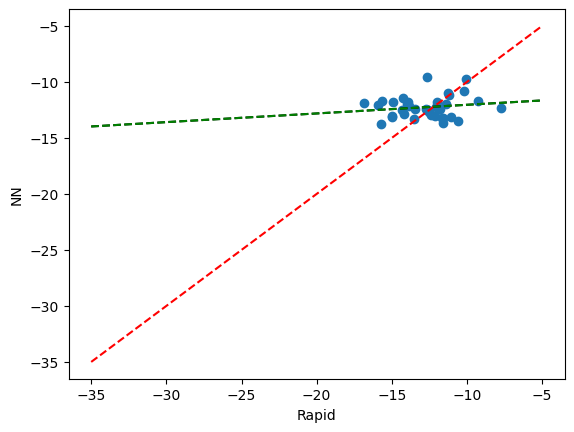

In [177]:
import matplotlib.pyplot as plt
plt.scatter(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)
# plt.scatter(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, t_merged_argo_2000.sel(time = transport.time, method = 'nearest').values)
plt.xlabel('Rapid')
plt.ylabel('NN')
plt.plot([-35, -5], [-35, -5], 'r--')

from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values.reshape(-1, 1), transport.values.reshape(-1, 1))
in_X = np.linspace(-35, -5, 100).reshape(-1, 1)
plt.plot(in_X, lr.predict(in_X), 'k--')
# lr = LinearRegression().fit(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values.reshape(-1, 1), t_merged_argo_2000.sel(time = transport.time, method = 'nearest').values.reshape(-1, 1))
in_X = np.linspace(-35, -5, 100).reshape(-1, 1)
plt.plot(in_X, lr.predict(in_X), 'g--')

In [178]:
plot_min = transport_t.time.min().values
plot_max = transport_t.time.max().values

plot_min, plot_max

(numpy.datetime64('2013-02-14T00:00:00.000000000'),
 numpy.datetime64('2021-12-29T00:00:00.000000000'))

In [179]:
train_y

<xarray.DataArray 'dv_dz_times_X' (time: 21)>
array([-14.77732582,  -9.04298548,  -9.38988042, -10.82491138,
       -12.6799816 ,  -7.78474228,  -7.6573467 , -12.94616411,
       -11.32151847,  -6.56028193,  -6.04778777, -11.55698276,
       -13.05504464, -10.06840438,  -9.5319937 , -13.3505497 ,
       -11.5143713 , -15.57959386,  -9.29463007, -15.91112157,
       -14.67266971])
Coordinates:
    z        float64 -1e+03
  * time     (time) datetime64[ns] 2004-04-02 2004-07-01 ... 2009-03-07

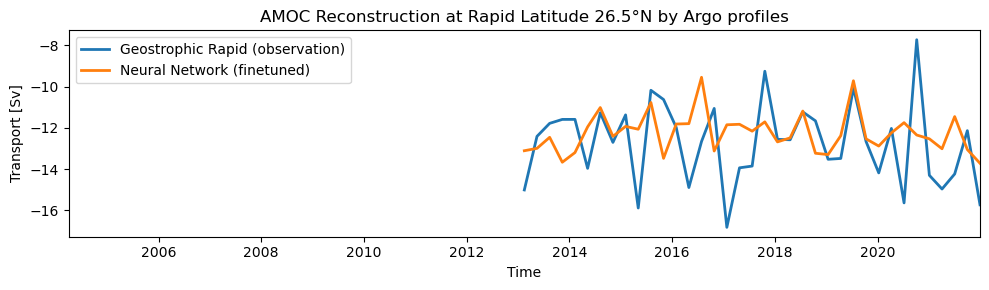

In [180]:
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1,1,1)

# calc = t_merged_argo_2000.sel(time = transport.time, method = 'nearest')
# ax.plot(calc.time, calc.values, label = 'Geostrohphic calculation from Argos', alpha = .5, color = 'black')
rapid = t_umo_obs.sel(time = transport.time, method = 'nearest')

transport_t = transport#.resample(time = '90D').mean()
rapid_t = rapid#.resample(time = '90D').mean()
# ax.plot(transport_orig.time, transport_orig.values, label = 'Neural Network (pretrained on VIKING20X)', linewidth = 2, zorder = 20)

ax.plot(rapid_t.time, rapid_t.dv_dz_times_X.values, label = 'Geostrophic Rapid (observation)', linewidth = 2)
ax.plot(transport_t.time, transport_t.values, label = 'Neural Network (finetuned)', linewidth = 2, zorder = 20)
# ax.plot(transport_raw_trained.time, transport_raw_trained.values, label = 'Neural Network (not pretrained)', linewidth = 2, zorder = 20)
ax.set_xlim(train_y.time.min().values, test_y.time.max().values)
plt.legend()
ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Time')
plt.title('AMOC Reconstruction at Rapid Latitude 26.5°N by Argo profiles')
fig.tight_layout()


plt.savefig('../rapid-geostrophic-reconstruction/argo_nn_reconstruction_obs.png')


# mae_error = mean_absolute_error(rapid_t.dv_dz_times_X.values, transport_t.values)

# print(f'R2: {r2_score(rapid_t.dv_dz_times_X.values, transport_t.values)}')
# print(f'MAE: {mae_error}; const MAE {const_prediction_MAE}', f' improvemqent percentage:  {(const_prediction_MAE - mae_error) / const_prediction_MAE * 100:.2f}%')
# print(f'MSE: {mean_squared_error(rapid_t.dv_dz_times_X.values, transport_t.values)}')

In [112]:
(rapid_t.dv_dz_times_X.values - transport_t.values).mean()

-2.7342932725290656

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


Text(0, 0.5, 'variance temperature')

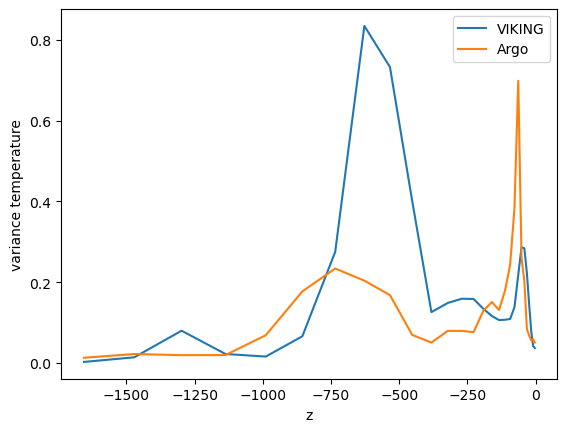

In [113]:
# After 2019 there is a large drift in the model temperatue therefore we select only the prior years.
a = ds_argo_merged_sim.where(ds_argo_merged_sim.z > -2000, drop = True).sel(time = ds_argo_merged_10days.time).sel(time = slice(None, '2019-01-01')).stack({'profile': ['time', 'pos']})

# salinity larger than 25 takes only valid measurment points as some are filled with zeros. 
a.where(a.profile_mask.any('z'), drop = True).temperature.where(a.salinity > 25).diff('z').var('profile').plot(label = 'VIKING')


b = ds_argo_merged_10days.sel(time = slice(None, '2019-01-01')).stack({'profile': ['time', 'pos']})

b.where(b.profile_mask.any('z'), drop = True).temperature.where(b.salinity > 25).diff('z').var('profile').plot(label = 'Argo')
plt.legend()

plt.ylabel('variance temperature')